# Конспект: прикладная статистика и A/B-тестирование

Переработанная версия конспекта в формате Jupyter Notebook. К каждому методу добавлен рабочий код на Python (numpy, pandas, scipy, statsmodels, pingouin) — с синтетическими данными, реальным запуском теста и выводом результата.

Это вторая версия: структура пересобрана так, чтобы темы шли последовательно, по логике изучения, а не в порядке исходного конспекта — ничего не используется раньше, чем объяснено. Добавлен также ряд тем, которых не хватало в оригинале: t- и F-критерии как отдельные темы (раньше использовались без введения), тесты для конверсии (биномиальное распределение, z-тест для пропорций, хи-квадрат), доверительные интервалы отдельным разделом, расширенные множественные сравнения (Benjamini-Hochberg/FDR, Dunnett), регуляризация, предварительная оценка дисперсии для размера выборки, sequential testing, байесовский подход к A/Б, интерференция/network effects, многорукие бандиты, A/A-тесты.

**Оглавление**

0. Перечень определений
1. t-критерий
2. F-критерий
3. Тесты для конверсии (биномиальное распределение, z-тест для пропорций, хи-квадрат)
4. Доверительные интервалы
5. U-критерий Манна-Уитни
6. Проверка распределения на нормальность
7. Проверка гомогенности дисперсий
8. Однофакторный ANOVA
9. Welch ANOVA
10. Многофакторный ANOVA
11. Множественные сравнения (post-hoc)
12. Параметрические / непараметрические тесты
13. Линейная регрессия
14. Множественные предикторы
15. Виды метрик
16. α, β, MDE, размер выборки
17. Бакеты
18. Линеаризация
19. Bootstrap
20. CUPED
21. Стратификация
22. Дельта-метод
23. Соление хэша
24. Sequential testing (проблема подглядывания)
25. Байесовский подход к A/B-тестированию
26. Интерференция и network effects
27. Многорукие бандиты
28. A/A-тесты
29. Ошибки в А/Б тестах
30. Разные разности (парадокс Симпсона, кластеризация)
31. Статьи

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4)
pd.set_option("display.precision", 4)

## 0. Перечень определений (из курса)

1. Репрезентативность
2. Виды выборок
3. Типы переменных
4. Меры центральной тенденции (мода, медиана, среднее)
5. Меры изменчивости (размах (R), дисперсия (D), среднеквадратическое отклонение (σ))
6. Квартили распределения и боксплот
7. Нормальное распределение (унимодально, симметрично, отклонения подчиняются закону)
8. Стандартизация (Z-преобразование)
9. Правило 2 и 3 сигм (68, 95, 100)
10. Центральная предельная теорема

   Если мы многократно берём случайные выборки из любого распределения с конечным средним и дисперсией, то распределение выборочных средних будет стремиться к нормальному по мере роста размера выборки.

   Говоря проще: даже если исходные данные не нормальны, средние значения по выборкам из этих данных будут распределены приближённо нормально, если выборка достаточно большая (обычно n ≥ 30).

   Именно благодаря ЦПТ мы можем использовать нормальное распределение для:
   - построения доверительных интервалов;
   - проведения t-тестов;
   - оценки параметров генеральной совокупности.

11. Стандартная ошибка среднего (SE)
12. Доверительный интервал (μ ± 1.96·SE, μ ± 2.58·SE) — подробный разбор формул для разных случаев в разделе 4.
13. Уровень значимости — вероятность получить такое или ещё большее значение при многократном повторении.
14. Ошибки первого и второго рода

   Ошибка 1-го рода (альфа, α) — это когда мы отвергаем верную нулевую гипотезу (ложная тревога, "эффект есть, а его нет"), а ошибка 2-го рода (бета, β) — это когда принимаем ложную нулевую гипотезу ("эффекта нет, а он есть"), и вероятность последней связана с мощностью критерия (1 − β). Эти ошибки взаимосвязаны: уменьшая одну, мы увеличиваем другую, и их нужно балансировать в зависимости от последствий.

15. T-распределение
   - унимодально;
   - симметрично;
   - но: наблюдения с большей вероятностью попадают за пределы ±2σ от M (более тяжёлые хвосты распределения).

   T-распределение используем потому, что на практике не знаем среднего в генеральной совокупности. Как именно оно используется в t-критерии — раздел 1.

16. Число степеней свободы — зависит от количества элементов в выборке. Чем больше элементов в выборке, тем больше число степеней свободы и тем больше распределение похоже на нормальное.

### Меры центральной тенденции и изменчивости на практике

Возьмём выборку — время сессии пользователя в секундах. Такие метрики обычно скошены вправо (много коротких сессий, немного очень длинных), поэтому среднее и медиана будут заметно расходиться — на этом примере это хорошо видно.

In [2]:
# 0.1
session_time = np.random.lognormal(mean=4.2, sigma=0.6, size=500)  # секунды

mean_ = session_time.mean()
median_ = np.median(session_time)
mode_ = stats.mode(session_time.round(-1), keepdims=True).mode[0]  # округляем, иначе мода не имеет смысла на непрерывных данных
range_ = session_time.max() - session_time.min()
var_ = session_time.var(ddof=1)      # выборочная дисперсия (D)
std_ = session_time.std(ddof=1)      # среднеквадратическое отклонение (σ)

print(f"Среднее (mean):        {mean_:.1f} сек")
print(f"Медиана (median):      {median_:.1f} сек")
print(f"Мода (mode, ~округл.): {mode_:.1f} сек")
print(f"Размах (R):            {range_:.1f} сек")
print(f"Дисперсия (D):         {var_:.1f}")
print(f"Ст. отклонение (σ):    {std_:.1f} сек")
print()
print("Среднее > медианы — типичный признак правой скошенности (длинный хвост из долгих сессий).")

Среднее (mean):        80.2 сек
Медиана (median):      67.2 сек
Мода (mode, ~округл.): 40.0 сек
Размах (R):            663.4 сек
Дисперсия (D):         3277.7
Ст. отклонение (σ):    57.3 сек

Среднее > медианы — типичный признак правой скошенности (длинный хвост из долгих сессий).


### Квартили и боксплот

Квартили делят упорядоченную выборку на 4 равные части. Q1 — 25-й перцентиль, Q2 — медиана, Q3 — 75-й перцентиль. Межквартильный размах IQR = Q3 − Q1 используется как устойчивая к выбросам мера разброса, а также как правило для определения выбросов: всё, что выходит за Q1 − 1.5·IQR или Q3 + 1.5·IQR, принято считать выбросом.

Q1 = 43.8, Q2 (медиана) = 67.2, Q3 = 97.7
IQR = 53.9
Границы выбросов: [-37.1, 178.6]
Число выбросов по правилу IQR: 24 из 500


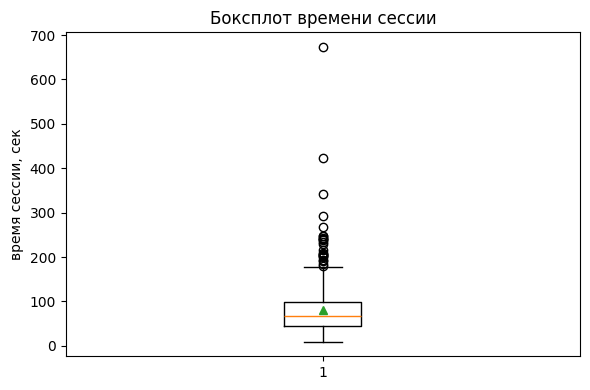

In [3]:
# 0.2
q1, q2, q3 = np.percentile(session_time, [25, 50, 75])
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
outliers = session_time[(session_time < lower_fence) | (session_time > upper_fence)]

print(f"Q1 = {q1:.1f}, Q2 (медиана) = {q2:.1f}, Q3 = {q3:.1f}")
print(f"IQR = {iqr:.1f}")
print(f"Границы выбросов: [{lower_fence:.1f}, {upper_fence:.1f}]")
print(f"Число выбросов по правилу IQR: {len(outliers)} из {len(session_time)}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(session_time, vert=True, showmeans=True)
ax.set_ylabel("время сессии, сек")
ax.set_title("Боксплот времени сессии")
plt.tight_layout()
plt.show()

### Правило 2 и 3 сигм (эмпирическое правило 68-95-99.7)

Для нормального распределения доля наблюдений в пределах ±1σ, ±2σ и ±3σ от среднего примерно постоянна и не зависит от конкретных параметров распределения — это и есть правило 68-95-99.7.

In [4]:
# 0.3
normal_sample = np.random.normal(loc=100, scale=15, size=100_000)
mu, sigma = normal_sample.mean(), normal_sample.std(ddof=1)

for k in [1, 2, 3]:
    within = np.mean(np.abs(normal_sample - mu) <= k * sigma)
    print(f"Доля наблюдений в пределах ±{k}σ: {within:.1%}")

print("\nТеоретические значения: 68.3%, 95.4%, 99.7%")

Доля наблюдений в пределах ±1σ: 68.2%
Доля наблюдений в пределах ±2σ: 95.5%
Доля наблюдений в пределах ±3σ: 99.7%

Теоретические значения: 68.3%, 95.4%, 99.7%


### Центральная предельная теорема — симуляция

Возьмём заведомо не нормальное распределение (экспоненциальное — сильно скошенное) и посмотрим, что происходит с распределением *выборочных средних*, если многократно брать из него выборки размера n и считать среднее по каждой.

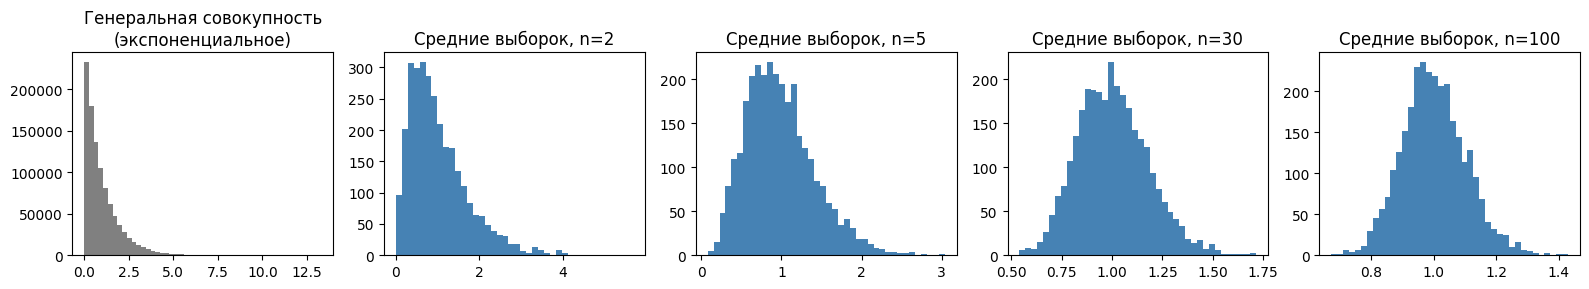

Уже при n=30 распределение выборочных средних выглядит близким к нормальному, хотя сама популяция экспоненциальная.


In [5]:
# 0.4
population = np.random.exponential(scale=1.0, size=1_000_000)

sample_sizes = [2, 5, 30, 100]
fig, axes = plt.subplots(1, len(sample_sizes) + 1, figsize=(16, 3))

axes[0].hist(population, bins=50, color="gray")
axes[0].set_title("Генеральная совокупность\n(экспоненциальное)")

for ax, n in zip(axes[1:], sample_sizes):
    sample_means = [population[np.random.randint(0, len(population), n)].mean() for _ in range(3000)]
    ax.hist(sample_means, bins=40, color="steelblue")
    ax.set_title(f"Средние выборок, n={n}")

plt.tight_layout()
plt.show()
print("Уже при n=30 распределение выборочных средних выглядит близким к нормальному, хотя сама популяция экспоненциальная.")

### Стандартная ошибка среднего

Стандартная ошибка среднего (SE) показывает, насколько сильно "гуляет" выборочное среднее от выборки к выборке:

$$SE = \frac{\sigma}{\sqrt{n}}$$

Как из неё строится доверительный интервал — раздел 4.

In [6]:
# 0.5
sample = np.random.normal(loc=200, scale=40, size=80)  # например, средний чек
n = len(sample)
x_bar = sample.mean()
s = sample.std(ddof=1)
se = s / np.sqrt(n)

print(f"Среднее: {x_bar:.2f}")
print(f"SE:      {se:.2f}")

Среднее: 209.33
SE:      5.06


### T-распределение против нормального

На практике мы не знаем σ генеральной совокупности и оцениваем её по выборке — это добавляет неопределённости, поэтому вместо нормального используется t-распределение. У него более тяжёлые хвосты, а форма зависит от числа степеней свободы (df = n − 1): чем больше df, тем ближе t-распределение к нормальному.

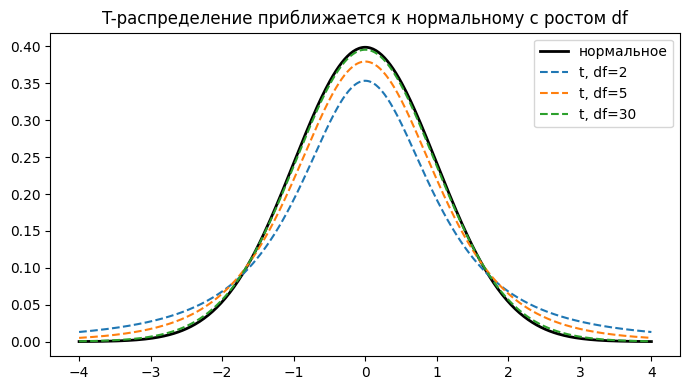

In [7]:
# 0.6
x = np.linspace(-4, 4, 400)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, stats.norm.pdf(x), label="нормальное", color="black", linewidth=2)
for df in [2, 5, 30]:
    ax.plot(x, stats.t.pdf(x, df), label=f"t, df={df}", linestyle="--")
ax.legend()
ax.set_title("T-распределение приближается к нормальному с ростом df")
plt.tight_layout()
plt.show()

### Ошибки первого и второго рода — симуляция

Проверим оба типа ошибок напрямую через симуляцию.

Ошибка I рода (α): многократно повторяем эксперимент, в котором H₀ верна (эффекта нет), и смотрим, как часто t-тест всё равно "находит" значимый эффект — в среднем это должно происходить примерно в α = 5% случаев.

Ошибка II рода (β): повторяем эксперимент, где эффект реально есть, и смотрим, как часто тест его пропускает.

In [8]:
# 0.7
alpha = 0.05
n_sims = 5000
n_per_group = 50

# Ошибка I рода: H0 верна (обе группы из одного распределения)
false_positives = 0
for _ in range(n_sims):
    a = np.random.normal(0, 1, n_per_group)
    b = np.random.normal(0, 1, n_per_group)
    _, p = stats.ttest_ind(a, b)
    if p < alpha:
        false_positives += 1

# Ошибка II рода: реальный эффект есть (небольшой сдвиг среднего)
true_effect = 0.3
false_negatives = 0
for _ in range(n_sims):
    a = np.random.normal(0, 1, n_per_group)
    b = np.random.normal(true_effect, 1, n_per_group)
    _, p = stats.ttest_ind(a, b)
    if p >= alpha:
        false_negatives += 1

print(f"Наблюдаемая ошибка I рода (H0 верна):   {false_positives/n_sims:.1%}  (ожидаем ≈ {alpha:.0%})")
print(f"Наблюдаемая ошибка II рода (H0 неверна): {false_negatives/n_sims:.1%}")
print(f"Мощность теста (1-β) при эффекте {true_effect}: {1 - false_negatives/n_sims:.1%}")

Наблюдаемая ошибка I рода (H0 верна):   4.7%  (ожидаем ≈ 5%)
Наблюдаемая ошибка II рода (H0 неверна): 68.6%
Мощность теста (1-β) при эффекте 0.3: 31.4%


## 1. t-критерий

Параметрический тест для сравнения среднего с эталоном или средних двух групп, использующий t-распределение (раздел 0) вместо нормального — потому что на практике мы не знаем истинную σ генеральной совокупности и оцениваем её по выборке.

**1. Одновыборочный t-test** — сравнивает среднее выборки с заданным (гипотетическим или историческим) значением. H₀: μ = μ₀.

$$t = \frac{\bar{x} - \mu_0}{s/\sqrt{n}}, \qquad df = n-1$$

**2. Двухвыборочный t-test Стьюдента (pooled variance)** — сравнивает средние двух независимых групп, предполагая, что дисперсии групп равны. H₀: μ₁ = μ₂.

$$t = \frac{\bar{x}_1 - \bar{x}_2}{s_p\sqrt{1/n_1+1/n_2}}, \qquad s_p^2 = \frac{(n_1-1)s_1^2+(n_2-1)s_2^2}{n_1+n_2-2}, \qquad df=n_1+n_2-2$$

**3. Двухвыборочный t-test Уэлча** — то же самое, но не требует равенства дисперсий (использует отдельную дисперсию каждой группы, а не общую pooled):

$$t = \frac{\bar{x}_1-\bar{x}_2}{\sqrt{s_1^2/n_1+s_2^2/n_2}}, \qquad df \approx \frac{(s_1^2/n_1+s_2^2/n_2)^2}{\dfrac{(s_1^2/n_1)^2}{n_1-1}+\dfrac{(s_2^2/n_2)^2}{n_2-1}}\ \text{(поправка Уэлча-Саттерсвейта)}$$

Это тот же самый принцип, что и Welch ANOVA (раздел 9) — только для двух групп, а не для трёх и более.

**4. Парный t-test** — для связанных измерений (одни и те же объекты до/после). Сводится к одновыборочному t-test на разностях $d_i = x_i - y_i$. H₀: средняя разность = 0.

$$t = \frac{\bar{d}}{s_d/\sqrt{n}}, \qquad df = n-1$$

Парный тест устраняет межпользовательскую изменчивость и поэтому обычно куда мощнее обычного независимого теста на тех же данных.

**Одновыборочный t-test** — выручка за последние 40 дней против исторического среднего.

In [9]:
# 1.1
np.random.seed(50)
daily_revenue = np.random.normal(1050, 120, 40)
historical_avg = 1000

t_stat, p_val = stats.ttest_1samp(daily_revenue, historical_avg)
print(f"Среднее по выборке: {daily_revenue.mean():.1f} (историческое: {historical_avg})")
print(f"Одновыборочный t-test: t = {t_stat:.2f}, p = {p_val:.4f}")
print(f"-> {'значимо отличается от исторического' if p_val < 0.05 else 'значимого отличия не обнаружено'}")

Среднее по выборке: 1071.3 (историческое: 1000)
Одновыборочный t-test: t = 3.68, p = 0.0007
-> значимо отличается от исторического


**Стьюдент vs Уэлч** — две группы с заметно разной дисперсией. Важный практический момент: `scipy.stats.ttest_ind` по умолчанию использует `equal_var=True` (классический Стьюдент с pooled variance) — про `equal_var=False` (Уэлч) нужно помнить явно.

In [10]:
# 1.2
np.random.seed(51)
group_low_var = np.random.normal(100, 10, 30)
group_high_var = np.random.normal(108, 35, 30)

t_student, p_student = stats.ttest_ind(group_low_var, group_high_var, equal_var=True)
t_welch, p_welch = stats.ttest_ind(group_low_var, group_high_var, equal_var=False)

print(f"Дисперсии групп: {group_low_var.var(ddof=1):.1f} vs {group_high_var.var(ddof=1):.1f}  (заметно разные)")
print(f"Student (equal_var=True, pooled):  t = {t_student:.3f}, p = {p_student:.4f}")
print(f"Welch (equal_var=False):           t = {t_welch:.3f}, p = {p_welch:.4f}")
print("\nЕсли дисперсии в группах разные, а вызвать ttest_ind без equal_var=False -- получится чуть смещённый результат.")

Дисперсии групп: 103.5 vs 645.4  (заметно разные)
Student (equal_var=True, pooled):  t = -1.152, p = 0.2541
Welch (equal_var=False):           t = -1.152, p = 0.2566

Если дисперсии в группах разные, а вызвать ttest_ind без equal_var=False -- получится чуть смещённый результат.


**Парный t-test** — время на сайте до/после изменения у одних и тех же пользователей (значения `after` специально построены так, чтобы сильно коррелировать с `before`, как и бывает у одного и того же человека).

In [11]:
# 1.3
np.random.seed(52)
n_users = 40
before = np.random.normal(300, 60, n_users)
after = before + 15 + np.random.normal(0, 20, n_users)   # тот же пользователь: сильно коррелирует с before, + эффект +15

t_paired, p_paired = stats.ttest_rel(after, before)
t_indep, p_indep = stats.ttest_ind(after, before)

print(f"Парный t-test:          t = {t_paired:.3f}, p = {p_paired:.4f}")
print(f"Обычный (независимый):  t = {t_indep:.3f}, p = {p_indep:.4f}")
print("\nЭто одни и те же данные, но парный тест убирает межпользовательскую изменчивость (у каждого свой уровень активности)")
print("и оставляет только шум самого эффекта -- поэтому обнаруживает его увереннее.")

Парный t-test:          t = 6.480, p = 0.0000
Обычный (независимый):  t = 1.572, p = 0.1200

Это одни и те же данные, но парный тест убирает межпользовательскую изменчивость (у каждого свой уровень активности)
и оставляет только шум самого эффекта -- поэтому обнаруживает его увереннее.


## 2. F-критерий

F-распределение возникает как отношение двух независимых величин хи-квадрат, каждая делённая на свои степени свободы. Поскольку оценки дисперсии (через s²) масштабированы по хи-квадрат, F-распределение естественно появляется всякий раз, когда сравниваются две дисперсии.

**Классический F-test на равенство двух дисперсий** (тот же самый тест, что фигурирует в разделе про гомогенность дисперсий):

$$F = \frac{s_1^2}{s_2^2}, \qquad H_0: \sigma_1^2 = \sigma_2^2, \qquad df_1=n_1-1,\ df_2=n_2-1$$

**F встречается ещё в двух местах конспекта, и это не совпадение:**
- в ANOVA F-статистика — это отношение межгрупповой дисперсии к внутригрупповой;
- в регрессии F-статистика (в выводе OLS) — отношение дисперсии, объяснённой моделью, к остаточной дисперсии (тест на то, что модель в целом значимо лучше, чем предсказание одним средним).

Во всех трёх случаях вопрос один и тот же: «это отношение двух дисперсий больше, чем можно было бы ожидать случайно при H₀?» — просто каждый раз это разные пары дисперсий.

**F-тест на равенство двух дисперсий.**

In [12]:
# 2.1
np.random.seed(60)
metric_a = np.random.normal(50, 8, 40)
metric_b = np.random.normal(50, 18, 40)

var_a, var_b = metric_a.var(ddof=1), metric_b.var(ddof=1)
f_stat = max(var_a, var_b) / min(var_a, var_b)
df1, df2 = (len(metric_a) - 1, len(metric_b) - 1) if var_a > var_b else (len(metric_b) - 1, len(metric_a) - 1)
p_val = 2 * min(stats.f.cdf(f_stat, df1, df2), 1 - stats.f.cdf(f_stat, df1, df2))

print(f"Дисперсии: A = {var_a:.1f}, B = {var_b:.1f}")
print(f"F = {f_stat:.3f} (df1={df1}, df2={df2}), p = {p_val:.4f}")
print(f"-> {'дисперсии значимо различаются' if p_val < 0.05 else 'значимого различия не обнаружено'}")

Дисперсии: A = 70.4, B = 432.7
F = 6.146 (df1=39, df2=39), p = 0.0000
-> дисперсии значимо различаются


**Форма F-распределения** при разных степенях свободы — асимметрично, всегда неотрицательно (это отношение двух неотрицательных величин).

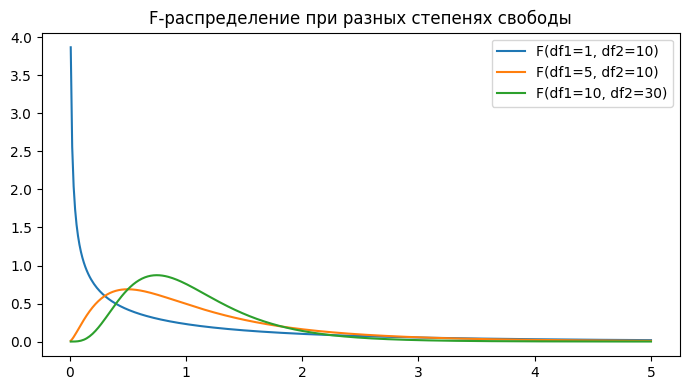

In [13]:
# 2.2
x = np.linspace(0.01, 5, 400)
fig, ax = plt.subplots(figsize=(7, 4))
for df1, df2 in [(1, 10), (5, 10), (10, 30)]:
    ax.plot(x, stats.f.pdf(x, df1, df2), label=f"F(df1={df1}, df2={df2})")
ax.legend()
ax.set_title("F-распределение при разных степенях свободы")
plt.tight_layout()
plt.show()

**F = t² для двух групп.** Если сравниваются ровно 2 группы, F-статистика из one-way ANOVA математически совпадает с квадратом t-статистики из двухвыборочного t-теста Стьюдента — это в буквальном смысле один и тот же тест, только записанный по-разному.

In [14]:
# 2.3
np.random.seed(61)
group1 = np.random.normal(100, 15, 35)
group2 = np.random.normal(107, 15, 35)

t_stat, p_t = stats.ttest_ind(group1, group2, equal_var=True)
f_stat_anova, p_f = stats.f_oneway(group1, group2)

print(f"t-test (Student):  t = {t_stat:.4f}, t^2 = {t_stat**2:.4f}, p = {p_t:.6f}")
print(f"One-way ANOVA:     F = {f_stat_anova:.4f},        p = {p_f:.6f}")
print(f"\nt^2 == F: {np.isclose(t_stat**2, f_stat_anova)}, p совпадают: {np.isclose(p_t, p_f)}")

t-test (Student):  t = -1.8075, t^2 = 3.2672, p = 0.075100
One-way ANOVA:     F = 3.2672,        p = 0.075100

t^2 == F: True, p совпадают: True


## 3. Тесты для конверсии

Конверсионные метрики (клик/не клик, купил/не купил) на уровне пользователя — это испытание Бернулли, а сумма кликов по группе — биномиальное распределение.

$$X \sim Binomial(n, p), \qquad E[X] = np, \qquad Var(X) = np(1-p)$$

**z-тест для пропорций** — сравнивает две конверсии (H₀: $p_1 = p_2$):

$$z = \frac{\hat{p}_1 - \hat{p}_2}{\sqrt{\hat{p}(1-\hat{p})\left(\frac{1}{n_1}+\frac{1}{n_2}\right)}}, \qquad \hat{p} = \frac{x_1+x_2}{n_1+n_2}\ \text{(объединённая пропорция)}$$

**Хи-квадрат тест** — проверяет независимость категориальных переменных в таблице сопряжённости:

$$\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$$

где $O_i$ — наблюдаемая частота, $E_i$ — ожидаемая при независимости.

Для сравнения **ровно двух** групп по биномиальному признаку z-тест для пропорций и хи-квадрат тест на таблице 2×2 — это один и тот же тест: $z^2 = \chi^2$, p-value идентичны. Разница в другом: хи-квадрат сразу обобщается на сравнение 3 и более групп (или вообще любую таблицу сопряжённости), а z-тест для пропорций — нет.

**Биномиальное распределение** для CTR-подобной метрики.

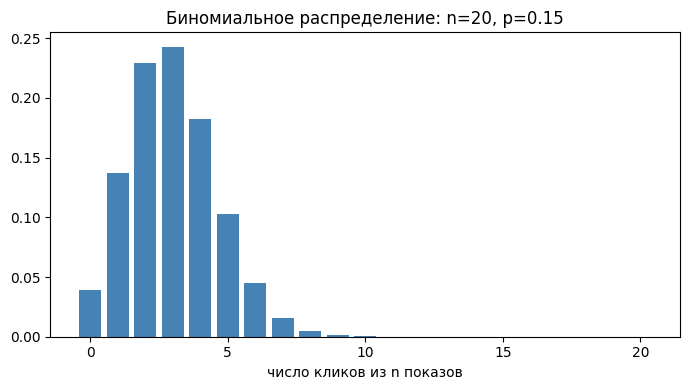

E[X] = np = 3.00
Var(X) = np(1-p) = 2.55


In [15]:
# 3.1
n_trials, p_success = 20, 0.15
x = np.arange(0, n_trials + 1)
pmf = stats.binom.pmf(x, n_trials, p_success)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x, pmf, color="steelblue")
ax.set_title(f"Биномиальное распределение: n={n_trials}, p={p_success}")
ax.set_xlabel("число кликов из n показов")
plt.tight_layout()
plt.show()

print(f"E[X] = np = {n_trials * p_success:.2f}")
print(f"Var(X) = np(1-p) = {n_trials * p_success * (1 - p_success):.2f}")

**z-тест для пропорций** — ручной расчёт по формуле и проверка через statsmodels.

In [16]:
# 3.2
from statsmodels.stats.proportion import proportions_ztest

n_control, conv_control = 5000, 410
n_test, conv_test = 5000, 460

p_control, p_test = conv_control / n_control, conv_test / n_test
p_pooled = (conv_control + conv_test) / (n_control + n_test)
se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1 / n_control + 1 / n_test))
z_manual = (p_test - p_control) / se_pooled
p_manual = 2 * (1 - stats.norm.cdf(abs(z_manual)))

z_sm, p_sm = proportions_ztest([conv_test, conv_control], [n_test, n_control])

print(f"Конверсия control: {p_control:.2%}, test: {p_test:.2%}")
print(f"Ручной расчёт:  z = {z_manual:.4f}, p = {p_manual:.4f}")
print(f"statsmodels:    z = {z_sm:.4f}, p = {p_sm:.4f}")

Конверсия control: 8.20%, test: 9.20%
Ручной расчёт:  z = 1.7741, p = 0.0760
statsmodels:    z = 1.7741, p = 0.0760


**z² = χ² на тех же данных.**

In [17]:
# 3.3
from scipy.stats import chi2_contingency

table = np.array([[conv_test, n_test - conv_test],
                   [conv_control, n_control - conv_control]])
chi2_stat, p_chi2, dof, expected = chi2_contingency(table, correction=False)

print(f"z^2  = {z_manual**2:.4f}   (p = {p_manual:.4f})")
print(f"chi2 = {chi2_stat:.4f}   (p = {p_chi2:.4f})")
print(f"\nСовпадают: статистика {np.isclose(z_manual**2, chi2_stat)}, p-value {np.isclose(p_manual, p_chi2)}")

z^2  = 3.1474   (p = 0.0760)
chi2 = 3.1474   (p = 0.0760)

Совпадают: статистика True, p-value True


**Хи-квадрат для 3+ вариантов** — то, что z-тест для пропорций сделать не может напрямую.

In [18]:
# 3.4
n_each = 2000
conv_a, conv_b, conv_c = 165, 190, 220   # три варианта кнопки

table3 = np.array([
    [conv_a, n_each - conv_a],
    [conv_b, n_each - conv_b],
    [conv_c, n_each - conv_c],
])
chi2_stat3, p_chi2_3, dof3, expected3 = chi2_contingency(table3, correction=False)

print("Конверсии:", {k: f"{v/n_each:.2%}" for k, v in zip("ABC", [conv_a, conv_b, conv_c])})
print(f"chi2 = {chi2_stat3:.3f}, df = {dof3}, p = {p_chi2_3:.4f}")
print(f"-> {'хотя бы один вариант отличается' if p_chi2_3 < 0.05 else 'значимых различий не обнаружено'}")

Конверсии: {'A': '8.25%', 'B': '9.50%', 'C': '11.00%'}
chi2 = 8.752, df = 2, p = 0.0126
-> хотя бы один вариант отличается


## 4. Доверительные интервалы

Общая структура любого доверительного интервала одна и та же: **точечная оценка ± критическое значение × стандартная ошибка**. Меняется только формула стандартной ошибки — в зависимости от того, что оценивается.

**Для одного среднего** (раздел 0):

$$\bar{x} \pm z_{\alpha/2}\cdot SE, \qquad SE = \frac{s}{\sqrt{n}}$$

**Для разницы средних двух групп** (A/B):

$$(\bar{x}_{test} - \bar{x}_{control}) \pm z_{\alpha/2}\sqrt{\frac{s_{test}^2}{n_{test}} + \frac{s_{control}^2}{n_{control}}}$$

**Для одной пропорции**:

$$\hat{p} \pm z_{\alpha/2}\sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

**Для разницы двух пропорций**:

$$(\hat{p}_{test} - \hat{p}_{control}) \pm z_{\alpha/2}\sqrt{\frac{\hat{p}_{test}(1-\hat{p}_{test})}{n_{test}} + \frac{\hat{p}_{control}(1-\hat{p}_{control})}{n_{control}}}$$

Важный нюанс: в z-тесте для пропорций (раздел 3) под H₀ используется **объединённая** (pooled) пропорция — тест проверяет гипотезу «пропорции равны», и SE считается в предположении, что это так. А доверительный интервал ничего не предполагает о равенстве — он оценивает фактическую величину разницы, поэтому использует **раздельные** пропорции каждой группы. Из-за этого SE для CI и SE, использованный внутри z-теста, в общем случае немного отличаются.

**ДИ для одного среднего.**

In [19]:
# 4.1
np.random.seed(70)
sample_mean_metric = np.random.normal(200, 40, 80)  # например, средний чек
n = len(sample_mean_metric)
x_bar = sample_mean_metric.mean()
se = sample_mean_metric.std(ddof=1) / np.sqrt(n)

ci_95 = (x_bar - 1.96 * se, x_bar + 1.96 * se)
ci_99 = (x_bar - 2.58 * se, x_bar + 2.58 * se)
print(f"Среднее: {x_bar:.2f}, SE: {se:.2f}")
print(f"95% ДИ: [{ci_95[0]:.2f}, {ci_95[1]:.2f}]")
print(f"99% ДИ: [{ci_99[0]:.2f}, {ci_99[1]:.2f}]")

Среднее: 196.32, SE: 4.35
95% ДИ: [187.79, 204.86]
99% ДИ: [185.09, 207.55]


**ДИ для разницы средних.**

In [20]:
# 4.2
n_test_ex, mean_test_ex, std_test_ex = 400, 105.0, 22.0
n_control_ex, mean_control_ex, std_control_ex = 400, 100.0, 20.0

diff = mean_test_ex - mean_control_ex
se_diff = np.sqrt(std_test_ex**2 / n_test_ex + std_control_ex**2 / n_control_ex)
z = stats.norm.ppf(0.975)
ci_low, ci_high = diff - z * se_diff, diff + z * se_diff

print(f"Разница средних (test - control): {diff:.2f}")
print(f"95% ДИ разницы: [{ci_low:.2f}, {ci_high:.2f}]")
print(f"-> {'0 не входит в ДИ, разница значима' if ci_low > 0 or ci_high < 0 else '0 входит в ДИ, разница не значима'}")

Разница средних (test - control): 5.00
95% ДИ разницы: [2.09, 7.91]
-> 0 не входит в ДИ, разница значима


**ДИ для одной пропорции и для разницы пропорций** — на данных из раздела 3.

In [21]:
# 4.3
p_hat = conv_control / n_control
se_p = np.sqrt(p_hat * (1 - p_hat) / n_control)
ci_p = (p_hat - 1.96 * se_p, p_hat + 1.96 * se_p)
print(f"Конверсия control: {p_hat:.2%}, 95% ДИ: [{ci_p[0]:.2%}, {ci_p[1]:.2%}]")

# для разницы пропорций - раздельные (unpooled) дисперсии, не объединённая, как в z-тесте
se_diff_p = np.sqrt(p_test * (1 - p_test) / n_test + p_control * (1 - p_control) / n_control)
diff_p = p_test - p_control
ci_diff_p = (diff_p - 1.96 * se_diff_p, diff_p + 1.96 * se_diff_p)
print(f"\nРазница конверсий (test - control): {diff_p:.2%}")
print(f"95% ДИ разницы (unpooled SE): [{ci_diff_p[0]:.2%}, {ci_diff_p[1]:.2%}]")
print(f"SE для ДИ (unpooled) = {se_diff_p:.5f}  vs  SE для z-теста (pooled) = {se_pooled:.5f}  -- близкие, но не идентичные числа.")

Конверсия control: 8.20%, 95% ДИ: [7.44%, 8.96%]

Разница конверсий (test - control): 1.00%
95% ДИ разницы (unpooled SE): [-0.10%, 2.10%]
SE для ДИ (unpooled) = 0.00564  vs  SE для z-теста (pooled) = 0.00564  -- близкие, но не идентичные числа.


## 5. U-критерий Манна-Уитни (Mann-Whitney U test)

Это непараметрический аналог t-теста (раздел 1) для двух независимых выборок.

Очень часто его неправильно трактуют как тест на разницу медиан. Это верно только если формы распределений одинаковы. Если формы разные — он проверяет более общую гипотезу «одно распределение стохастически больше другого».

Он проверяет гипотезу:
- H₀: распределения в группах одинаковы (часто интерпретируют как равенство медиан)
- H₁: распределения различаются

Важно: он не сравнивает средние, а сравнивает порядок значений (ранги).
- Берёт все значения из двух групп
- Сортирует их
- Присваивает ранги: 1, 2, 3, …
- Смотрит, какие ранги чаще принадлежат какой группе
- Если одна группа систематически «выше» другой → тест это обнаружит

**Почему Mann-Whitney устойчив к выбросам** — ему не важно, насколько значение большое, ему важен только порядок.

**Когда применяют Mann-Whitney вместо t-теста**
- данные сильно не нормальные;
- есть выбросы;
- малые выборки;
- метрика порядковая (ordinal);
- нарушены допущения t-теста.

Пример из конспекта: группа A содержит выброс (1000), группа B — нет. t-тест сильно реагирует на выброс, Mann-Whitney — почти нет, потому что он видит только то, что 1000 — это просто самый большой ранг.

In [22]:
# 5.1
group_a = np.array([1, 2, 3, 1000])
group_b = np.array([4, 5, 6, 7])

u_stat, p_mw = stats.mannwhitneyu(group_a, group_b, alternative="two-sided")
t_stat, p_t = stats.ttest_ind(group_a, group_b)

print("Группа A:", group_a)
print("Группа B:", group_b)
print()
print(f"t-test:        t = {t_stat:.3f}, p = {p_t:.3f}   (среднее A = {group_a.mean():.1f} — выброс тянет его сильно вверх)")
print(f"Mann-Whitney:   U = {u_stat:.3f}, p = {p_mw:.3f}   (ранги: A получает ранги {stats.rankdata(np.r_[group_a, group_b])[:4]})")

Группа A: [   1    2    3 1000]
Группа B: [4 5 6 7]

t-test:        t = 0.986, p = 0.362   (среднее A = 251.5 — выброс тянет его сильно вверх)
Mann-Whitney:   U = 4.000, p = 0.343   (ранги: A получает ранги [1. 2. 3. 8.])


Тот же эффект, но на более реалистичном размере выборки: два набора данных с одинаковым "типичным" уровнем, но в одном есть немного экстремальных выбросов (например, пара китов по выручке).

In [23]:
# 5.2
n = 60
typical_a = np.random.normal(100, 15, n)
typical_b = np.random.normal(100, 15, n)

outlier_a = np.r_[typical_a, [900, 950, 1000]]
outlier_b = typical_b

t_stat, p_t = stats.ttest_ind(outlier_a, outlier_b)
u_stat, p_mw = stats.mannwhitneyu(outlier_a, outlier_b, alternative="two-sided")

print(f"Средние: A = {outlier_a.mean():.1f}, B = {outlier_b.mean():.1f}  (среднее A взвинчено тремя выбросами)")
print(f"Медианы: A = {np.median(outlier_a):.1f}, B = {np.median(outlier_b):.1f}  (медиана почти не сдвинулась)")
print()
print(f"t-test:        p = {p_t:.4f}  -> {'значимо' if p_t < 0.05 else 'не значимо'} (тест введён в заблуждение выбросами)")
print(f"Mann-Whitney:   p = {p_mw:.4f}  -> {'значимо' if p_mw < 0.05 else 'не значимо'} (опирается на ранги, устойчивее)")

Средние: A = 140.5, B = 100.5  (среднее A взвинчено тремя выбросами)
Медианы: A = 101.5, B = 97.4  (медиана почти не сдвинулась)

t-test:        p = 0.0947  -> не значимо (тест введён в заблуждение выбросами)
Mann-Whitney:   p = 0.5354  -> не значимо (опирается на ранги, устойчивее)


## 6. Проверка распределения на нормальность

Графические методы: QQ-плот, гистограмма распределения.

В современном Data Science (особенно в A/B-тестах на больших данных) формальные тесты всё чаще заменяют визуальным анализом (Q-Q Plots) и бутстрапом. Тесты на нормальность на больших выборках почти всегда дают p-value < 0.05 (отклоняют нормальность), даже если отклонение ничтожно и не влияет на работу t-теста.

| Место | Тест | Что проверяет | Плюсы | Минусы |
|---|---|---|---|---|
| 1 | Шапиро-Уилка (Shapiro-Wilk) | Корреляцию между данными и идеальными нормальными квантилями | Золотой стандарт, наибольшая мощность среди тестов на нормальность | Ограничение по количеству данных (обычно до 5000 наблюдений в старых реализациях) |
| 2 | Колмогорова-Смирнова (с поправкой Лиллиефорса) | Сравнивает эмпирическую функцию распределения с теоретической нормальной | Понятная визуальная интерпретация, широко известен | Низкая мощность, часто «пропускает» ненормальность на малых выборках |
| 3 | Андерсона-Дарлинга | Модификация K-S, придающая больше веса «хвостам» | Лучше находит отклонения в хвостах | Критические значения зависят от конкретного распределения |
| 4 | Д'Агостино K² (асимметрия + эксцесс) | Комбинирует skew и kurtosis | Показывает, *почему* распределение не нормально | Требует средних/больших выборок |
| 5 | Харке-Бера (Jarque-Bera) | Тоже асимметрия + эксцесс | Популярен в эконометрике и анализе временных рядов | На малых выборках нестабилен, чувствителен к выбросам |

Статистическая мощность у тестов разная: Шапиро-Уилка — самый мощный (лучше всех замечает даже небольшие отклонения), но у него историческое ограничение по размеру выборки; Д'Агостино K² — более «грубый», но часто более адекватный для реальных задач А/Б-тестирования, так как не придирается к микро-отклонениям, которые не влияют на работу t-теста.

Сравним нормальную выборку и скошенную (экспоненциальную) — сначала визуально, затем всеми пятью тестами.

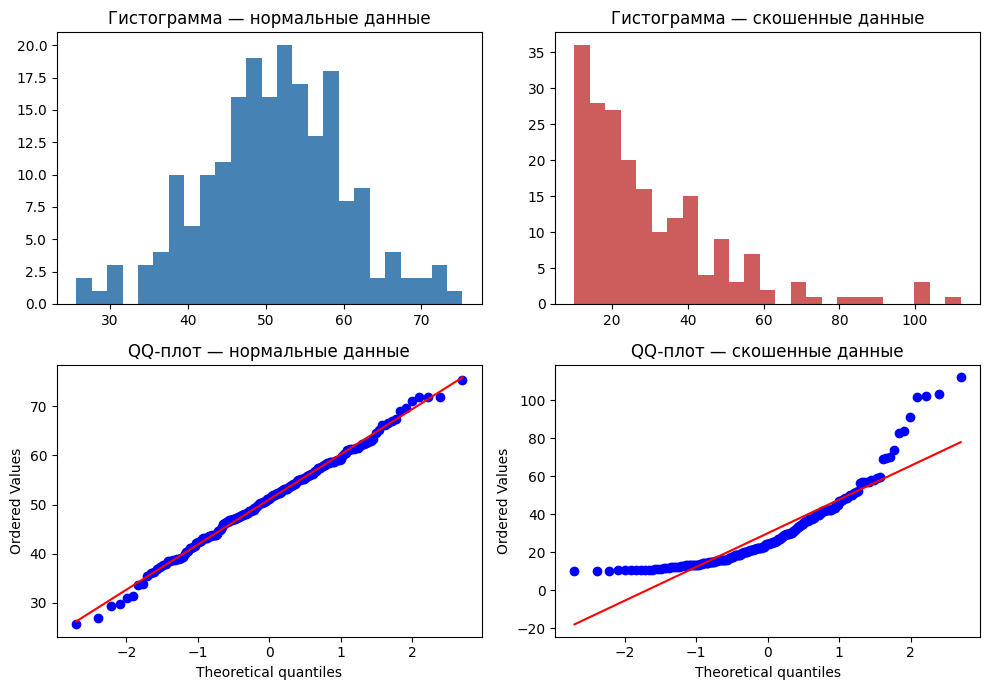

На QQ-плоте нормальные данные ложатся на прямую линию, скошенные — заметно от неё отклоняются на хвостах.


In [24]:
# 6.1
np.random.seed(1)
normal_data = np.random.normal(50, 10, 200)
skewed_data = np.random.exponential(20, 200) + 10

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].hist(normal_data, bins=25, color="steelblue")
axes[0, 0].set_title("Гистограмма — нормальные данные")

axes[0, 1].hist(skewed_data, bins=25, color="indianred")
axes[0, 1].set_title("Гистограмма — скошенные данные")

stats.probplot(normal_data, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ-плот — нормальные данные")

stats.probplot(skewed_data, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("QQ-плот — скошенные данные")

plt.tight_layout()
plt.show()
print("На QQ-плоте нормальные данные ложатся на прямую линию, скошенные — заметно от неё отклоняются на хвостах.")

In [25]:
# 6.2
from statsmodels.stats.diagnostic import lilliefors

def normality_report(data, label):
    shapiro_stat, shapiro_p = stats.shapiro(data)
    ks_stat, ks_p = lilliefors(data, dist="norm")
    ad_result = stats.anderson(data, dist="norm")
    ad_crit_5pct = ad_result.critical_values[2]  # уровень 5%
    dagostino_stat, dagostino_p = stats.normaltest(data)
    jb_stat, jb_p = stats.jarque_bera(data)

    return pd.DataFrame({
        "тест": ["Shapiro-Wilk", "Kolmogorov-Smirnov (Lilliefors)", "Anderson-Darling", "D'Agostino K2", "Jarque-Bera"],
        "статистика": [shapiro_stat, ks_stat, ad_result.statistic, dagostino_stat, jb_stat],
        "p-value / порог": [shapiro_p, ks_p, f"crit(5%)={ad_crit_5pct:.3f}", dagostino_p, jb_p],
        "вывод (α=0.05)": [
            "не нормально" if shapiro_p < 0.05 else "нормально",
            "не нормально" if ks_p < 0.05 else "нормально",
            "не нормально" if ad_result.statistic > ad_crit_5pct else "нормально",
            "не нормально" if dagostino_p < 0.05 else "нормально",
            "не нормально" if jb_p < 0.05 else "нормально",
        ],
    }).assign(выборка=label)

report = pd.concat([
    normality_report(normal_data, "нормальные данные"),
    normality_report(skewed_data, "скошенные данные"),
], ignore_index=True)
report

/tmp/ipykernel_81/930773809.py:7: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_result = stats.anderson(data, dist="norm")


,тест,статистика,p-value / порог,вывод (α=0.05),выборка
0,Shapiro-Wilk,0.9959,0.867,нормально,нормальные данные
1,Kolmogorov-Smirnov (Lilliefors),0.0375,0.7163,нормально,нормальные данные
2,Anderson-Darling,0.2011,crit(5%)=0.749,нормально,нормальные данные
3,D'Agostino K2,0.5154,0.7728,нормально,нормальные данные
4,Jarque-Bera,0.3100,0.8564,нормально,нормальные данные
5,Shapiro-Wilk,0.8324,0.0,не нормально,скошенные данные
6,Kolmogorov-Smirnov (Lilliefors),0.1504,0.001,не нормально,скошенные данные
7,Anderson-Darling,8.2072,crit(5%)=0.749,не нормально,скошенные данные
8,D'Agostino K2,78.6134,0.0,не нормально,скошенные данные
9,Jarque-Bera,209.4273,0.0,не нормально,скошенные данные


То же самое через pingouin, в формате из конспекта — с группировкой по колонке (`pg.normality(data=..., dv=..., group=..., method="shapiro")`):

In [26]:
# 6.3
import pingouin as pg

df_likes = pd.DataFrame({
    "likes": np.r_[normal_data, skewed_data],
    "button": ["A"] * len(normal_data) + ["B"] * len(skewed_data),
})

pg.normality(data=df_likes, dv="likes", group="button", method="shapiro")

,W,pval,normal
button,,,
A,0.9959,8.6696e-01,True
B,0.8324,6.5071e-14,False


Иллюстрация ключевого предостережения из конспекта: на больших выборках формальные тесты почти всегда отклоняют нормальность, даже при почти незаметном отклонении.

In [27]:
# 6.4
np.random.seed(0)
almost_normal_small = np.random.normal(0, 1, 100) + np.random.normal(0, 0.01, 100)  # микро-отклонение
almost_normal_large = np.random.normal(0, 1, 50_000) + np.random.normal(0, 0.01, 50_000)

for label, sample in [("n=100", almost_normal_small), ("n=50000", almost_normal_large)]:
    _, p = stats.shapiro(sample) if len(sample) <= 5000 else stats.normaltest(sample)
    print(f"{label}: p-value = {p:.5f} -> {'отклоняем нормальность' if p < 0.05 else 'не отклоняем'}")

print("\nОдно и то же (почти незаметное) отклонение от нормальности: на маленькой выборке тест его не видит, на большой — видит и отклоняет H0, хотя визуально данные почти неотличимы от нормальных.")

n=100: p-value = 0.84357 -> не отклоняем
n=50000: p-value = 0.07709 -> не отклоняем

Одно и то же (почти незаметное) отклонение от нормальности: на маленькой выборке тест его не видит, на большой — видит и отклоняет H0, хотя визуально данные почти неотличимы от нормальных.


## 7. Проверка гомогенности дисперсий

Гомогенность дисперсий (homoscedasticity) — это предположение, что дисперсии в сравниваемых группах примерно равны. Это одно из базовых допущений t-теста и ANOVA. Если оно нарушено, обычный t-test и ANOVA дают некорректные p-values, и возрастает риск ложных выводов.

| Место | Тест | Что проверяет | Плюсы | Минусы |
|---|---|---|---|---|
| 1 | Левена (Levene), самый частый | Отклонения от **среднего** | Устойчив к ненормальности, стандарт в индустрии | Менее мощный, чем Бартлетт, если данные идеально нормальны |
| 2 | Бартлетта (Bartlett) | Логарифмы выборочных дисперсий против взвешенного среднего логарифма, предполагая нормальность | Высокая мощность при строгом соблюдении нормальности | Чудовищная чувствительность к ненормальности — покажет различие там, где его нет |
| 3 | F-тест Фишера (раздел 2) | Отношение двух дисперсий | Простота расчёта и понимания | Работает только для ровно двух групп, крайне чувствителен к ненормальности |
| 4 | Брауна-Форсайта | Модификация Левена, использующая **медиану** вместо среднего | Максимальная робастность к тяжёлым хвостам и выбросам | Чуть меньшая мощность, чем у классического Левена на «чистых» данных |
| 5 | Флигнера-Килина | Непараметрический, на рангах | Почти не зависит от вида распределения, не боится выбросов | Сложнее в интерпретации, реже встречается «из коробки» |

Статистическая мощность теста на гомогенность — это способность обнаружить различие дисперсий, если оно реально существует. Более мощные тесты (Bartlett) чувствительнее, но менее устойчивы к нарушению нормальности; менее мощные (Levene, Fligner) более надёжны для реальных данных.

Три группы (как в конспекте — `ss.levene(red, green, blue)`), но с разными дисперсиями: red и green сопоставимы, у blue дисперсия намного выше.

In [28]:
# 7.1
np.random.seed(3)
red = np.random.normal(50, 5, 80)
green = np.random.normal(52, 5, 80)
blue = np.random.normal(65, 20, 80)   # намного шумнее и с более высоким средним

levene_mean = stats.levene(red, green, blue, center="mean")     # классический Levene
levene_median = stats.levene(red, green, blue, center="median") # Brown-Forsythe
bartlett_stat, bartlett_p = stats.bartlett(red, green, blue)
fligner_stat, fligner_p = stats.fligner(red, green, blue)

# F-тест Фишера (раздел 2) - только для двух групп (red vs green)
var_r, var_g = red.var(ddof=1), green.var(ddof=1)
f_stat = max(var_r, var_g) / min(var_r, var_g)
df1, df2 = (len(red) - 1, len(green) - 1) if var_r > var_g else (len(green) - 1, len(red) - 1)
f_p = 2 * min(stats.f.cdf(f_stat, df1, df2), 1 - stats.f.cdf(f_stat, df1, df2))

summary = pd.DataFrame({
    "тест": ["Levene (mean)", "Levene/Brown-Forsythe (median)", "Bartlett", "Fligner-Killeen", "F-test (red vs green)"],
    "статистика": [levene_mean.statistic, levene_median.statistic, bartlett_stat, fligner_stat, f_stat],
    "p-value": [levene_mean.pvalue, levene_median.pvalue, bartlett_p, fligner_p, f_p],
})
summary["вывод (α=0.05)"] = np.where(summary["p-value"] < 0.05, "дисперсии различаются", "дисперсии однородны")
summary

,тест,статистика,p-value,вывод (α=0.05)
0,Levene (mean),57.7096,3.8118e-21,дисперсии различаются
1,Levene/Brown-Forsythe (median),51.3479,2.9750e-19,дисперсии различаются
2,Bartlett,221.0092,1.0197e-48,дисперсии различаются
3,Fligner-Killeen,77.0476,1.8592e-17,дисперсии различаются
4,F-test (red vs green),1.5913,4.0480e-02,дисперсии различаются


И версия из конспекта через pingouin (`pg.homoscedasticity`), тоже реализующая тест Левена:

In [29]:
# 7.2
df_groups = pd.DataFrame({
    "likes": np.r_[red, green, blue],
    "button": ["red"] * len(red) + ["green"] * len(green) + ["blue"] * len(blue),
})
pg.homoscedasticity(data=df_groups, dv="likes", group="button")

,W,pval,equal_var
levene,51.3479,2.9750e-19,False


## 8. Однофакторный ANOVA (One-way ANOVA)

Параметрический тест для сравнения средних значений количественной метрики в более чем двух независимых группах по одному категориальному фактору. Обобщение двухвыборочного t-теста (раздел 1) на 3 и более групп.

Пример: есть 3 версии кнопки → сравниваем среднее число кликов.
- H₀ (нулевая): средние всех групп равны
- H₁ (альтернативная): хотя бы одно среднее отличается

Сравнивает вариацию между группами с вариацией внутри групп через F-статистику (раздел 2): если между > внутри → эффект фактора значим.

**Основные допущения**
- наблюдения независимы;
- в каждой группе распределение близко к нормальному;
- дисперсии гомогенны (равны).

**Когда применять**: 1 фактор (A/B/C/…), количественная метрика, дисперсии примерно равны, нет сильных выбросов.

**Что делать после ANOVA**: если p-value < α → нужен post-hoc тест (раздел 11), чтобы узнать, какие именно группы отличаются.

Продолжим на тех же трёх группах (red/green/blue), что и в разделе про гомогенность дисперсий, — там мы уже выяснили, что дисперсия blue заметно выше остальных.

In [30]:
# 8.1
f_stat, p_anova = stats.f_oneway(red, green, blue)
print(f"Классический one-way ANOVA: F = {f_stat:.3f}, p = {p_anova:.4f}")
print(f"-> {'есть значимые различия между группами' if p_anova < 0.05 else 'значимых различий не обнаружено'}")
print()

anova_table = pg.anova(data=df_groups, dv="likes", between="button", detailed=True)
anova_table

Классический one-way ANOVA: F = 44.355, p = 0.0000
-> есть значимые различия между группами



,Source,SS,DF,MS,F,p_unc,np2
0,button,13632.6668,2,6816.3334,44.3553,4.3361e-17,0.2724
1,Within,36421.1453,237,153.6757,NaN,NaN,NaN


## 9. Welch ANOVA

Модификация однофакторного ANOVA, устойчивая к неравным дисперсиям и разным размерам групп. То же самое, что Welch t-test (раздел 1), но для >2 групп.

| | Классический ANOVA | Welch ANOVA |
|---|---|---|
| Равенство дисперсий | Требует | Не требует |
| Дисперсия | Использует pooled variance | Использует взвешенные дисперсии |
| Дисбаланс групп | Чувствителен | Устойчив |
| Мощность | Более мощный при выполнении допущений | Менее мощный, но более надёжный |

**Когда применять**: Levene / Brown-Forsythe показал неравенство дисперсий, группы разного размера, есть сомнения в гомогенности.

**Post-hoc после Welch ANOVA**: Games–Howell test (раздел 11).

Так как мы уже знаем (по тесту Левена из раздела 7), что дисперсии red/green/blue не равны, Welch ANOVA — более корректный выбор, чем классический. Сравним оба результата напрямую.

In [31]:
# 9.1
welch_table = pg.welch_anova(data=df_groups, dv="likes", between="button")
print("Классический ANOVA: p =", round(p_anova, 4))
print("Welch ANOVA:         p =", round(welch_table["p_unc"].iloc[0], 4))
welch_table

Классический ANOVA: p = 0.0
Welch ANOVA:         p = 0.0


,Source,ddof1,ddof2,F,p_unc,np2
0,button,2,140.496,26.5082,1.7076e-10,0.2724


## 10. Многофакторный ANOVA

Используется, когда на метрику влияет несколько категориальных факторов. Позволяет одновременно оценить основные эффекты факторов и их взаимодействие — важно, чтобы понять, одинаков ли эффект, например, рекламы для разных возрастных групп.

Это A/B/C/D тесты + сегментация. Позволяет проверить:
1. основной эффект фактора A (ads);
2. основной эффект фактора B (age_group);
3. эффект взаимодействия A×B (interaction).

Для каждого эффекта: H₀ — фактор не влияет на среднее, H₁ — влияет. Это не «много тестов», а один общий подход с разными аспектами анализа — не один A/B тест, а эксперимент с двумя факторами.

**Зачем несколько моделей**

Модель без взаимодействия (main effects): `clicks ~ C(ads) + C(age_group)` — проверяет, влияет ли ads в среднем и влияет ли age_group в среднем, но НЕ проверяет, меняется ли эффект ads в разных age_group.

Модель с взаимодействием: `clicks ~ C(ads) * C(age_group)`, эквивалентно `clicks ~ ads + age_group + ads:age_group` — дополнительно проверяет, одинаков ли эффект рекламы для всех возрастов.

**Что такое interaction**: если оно есть — реклама A лучше для молодых, реклама B лучше для пожилых (или наоборот). Если его нет — одна реклама лучше одинаково для всех возрастов. Это важный бизнес-смысл: нельзя сказать «лучшая реклама» без указания сегмента.

**ss_type (Type I / II / III)** — про то, как делится вариация между факторами, особенно если данные не сбалансированы:
- **Type I** (последовательный): факторы учитываются по порядку — сначала вклад ads, потом age_group с учётом ads. Если поменять порядок факторов, результат меняется. Используется редко, в основном учебно.
- **Type II**: каждый фактор проверяется с учётом других факторов, но без interaction. Подходит, если interaction незначим и дизайн сбалансирован. Используется часто.
- **Type III**: каждый фактор проверяется с учётом всех остальных, включая interaction. Самый строгий вариант — когда есть interaction или дизайн несбалансирован.

Смоделируем ровно тот пример, что в конспекте: клики (`clicks`) в зависимости от типа рекламы (`ads`) и возрастной группы (`age_group`). Специально заложим "перекрёстный" эффект: реклама A работает лучше для молодых, реклама B — для пожилых, а *в среднем* по каждой рекламе и по каждой возрастной группе эффекта почти нет. Это ситуация, где interaction есть, а main effects — нет, и её легко проглядеть, если не строить модель с взаимодействием.

In [32]:
# 10.1
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

np.random.seed(7)
n_per_cell = 60
cell_config = [("A", "young", 12), ("B", "young", 8), ("A", "old", 8), ("B", "old", 12)]

rows = []
for ads_val, age_val, mean_clicks in cell_config:
    rows.append(pd.DataFrame({
        "clicks": np.random.poisson(mean_clicks, n_per_cell),
        "ads": ads_val,
        "age_group": age_val,
    }))
ads_clicks = pd.concat(rows, ignore_index=True)

print(ads_clicks.groupby(["ads", "age_group"])["clicks"].mean().unstack())

age_group      old  young
ads                      
A           7.9667  12.10
B          12.2500   7.45


In [33]:
# 10.2
model_main = smf.ols("clicks ~ C(ads) + C(age_group)", data=ads_clicks).fit()
print("Модель без взаимодействия:")
print(anova_lm(model_main, typ=2))
print()

model_interact = smf.ols("clicks ~ C(ads) * C(age_group)", data=ads_clicks).fit()
print("Модель со взаимодействием:")
print(anova_lm(model_interact, typ=2))

Модель без взаимодействия:
                 sum_sq     df       F  PR(>F)
C(ads)           2.0167    1.0  0.1332  0.7155
C(age_group)     6.6667    1.0  0.4403  0.5076
Residual      3588.5000  237.0     NaN     NaN

Модель со взаимодействием:
                        sum_sq     df         F      PR(>F)
C(ads)                  2.0167    1.0    0.1990  6.5593e-01
C(age_group)            6.6667    1.0    0.6579  4.1812e-01
C(ads):C(age_group)  1197.0667    1.0  118.1332  1.4184e-22
Residual             2391.4333  236.0       NaN         NaN


Как и ожидалось: в модели без взаимодействия ни `ads`, ни `age_group` не выглядят значимыми (эффекты гасят друг друга при усреднении). В модели со взаимодействием сам член `ads:age_group` — сильно значим: реклама явно работает по-разному в разных возрастных группах, просто это не видно, если смотреть только на средние эффекты.

In [34]:
# 10.3
pg.anova(data=ads_clicks, dv="clicks", between=["ads", "age_group"], effsize="n2")

,Source,SS,DF,MS,F,p_unc,n2
0,ads,2.0167,1,2.0167,0.1990,6.5593e-01,0.0006
1,age_group,6.6667,1,6.6667,0.6579,4.1812e-01,0.0019
2,ads * age_group,1197.0667,1,1197.0667,118.1332,1.4184e-22,0.3328
3,Residual,2391.4333,236,10.1332,NaN,NaN,NaN


**ss_type на практике.** Отличия между типами сумм квадратов проявляются только при несбалансированном дизайне (разное число наблюдений в ячейках). Создадим несбалансированную версию тех же данных и посмотрим, как Type I реагирует на порядок факторов в формуле, в отличие от Type II/III.

In [35]:
# 10.4
np.random.seed(11)
unbalanced_config = [("A", "young", 12, 80), ("B", "young", 8, 20), ("A", "old", 8, 15), ("B", "old", 12, 65)]
rows = []
for ads_val, age_val, mean_clicks, n in unbalanced_config:
    rows.append(pd.DataFrame({"clicks": np.random.poisson(mean_clicks, n), "ads": ads_val, "age_group": age_val}))
unbalanced = pd.concat(rows, ignore_index=True)
print("Размеры групп (несбалансированно):")
print(unbalanced.groupby(["ads", "age_group"]).size().unstack())

model_order1 = smf.ols("clicks ~ C(ads) + C(age_group)", data=unbalanced).fit()
model_order2 = smf.ols("clicks ~ C(age_group) + C(ads)", data=unbalanced).fit()

print("\nType I, порядок ads -> age_group:")
print(anova_lm(model_order1, typ=1))
print("\nType I, порядок age_group -> ads (тот же набор данных, другой порядок в формуле):")
print(anova_lm(model_order2, typ=1))
print("\n-> суммы квадратов для одних и тех же факторов отличаются в зависимости от порядка — это и есть особенность Type I.")

print("\nType II (не зависит от порядка):")
print(anova_lm(model_order1, typ=2))

Размеры групп (несбалансированно):
age_group  old  young
ads                  
A           15     80
B           65     20

Type I, порядок ads -> age_group:
                 df     sum_sq  mean_sq       F  PR(>F)
C(ads)          1.0    11.7067  11.7067  0.9342  0.3351
C(age_group)    1.0     0.0729   0.0729  0.0058  0.9393
Residual      177.0  2217.9704  12.5309     NaN     NaN

Type I, порядок age_group -> ads (тот же набор данных, другой порядок в формуле):
                 df     sum_sq  mean_sq       F  PR(>F)
C(age_group)    1.0     5.2900   5.2900  0.4222  0.5167
C(ads)          1.0     6.4896   6.4896  0.5179  0.4727
Residual      177.0  2217.9704  12.5309     NaN     NaN

-> суммы квадратов для одних и тех же факторов отличаются в зависимости от порядка — это и есть особенность Type I.

Type II (не зависит от порядка):
                 sum_sq     df       F  PR(>F)
C(ads)           6.4896    1.0  0.5179  0.4727
C(age_group)     0.0729    1.0  0.0058  0.9393
Residual      2217.

## 11. Множественные сравнения (post-hoc, парные t-тесты)

Все парные t-тесты после ANOVA — это не «другие тесты», а продолжение ANOVA.

**Чем отличается Tukey от pairwise t-test + Holm.** Tukey — специально выведенная формула под множественные сравнения. Holm — коррекция p-value после обычных t-тестов. Они решают одну задачу, но Tukey более оптимален, чаще используется и является стандартом де-факто после ANOVA.

**Типичная ошибка** — это когда:
- делают Tukey при неравных дисперсиях;
- делают Mann-Whitney, когда нужен ответ про среднее;
- делают post-hoc без глобального теста.

**Резюме.** При сравнении более чем двух групп сначала применяется глобальный тест (ANOVA или её непараметрический аналог). Если он показывает значимость, выполняются post-hoc тесты с коррекцией на множественные сравнения.

- Параметрические данные, равные дисперсии, все пары друг с другом: ANOVA → **Tukey**.
- Параметрические данные, неравные дисперсии: Welch ANOVA → **Games–Howell**.
- Параметрические данные, несколько вариантов против ОДНОГО контроля (а не все пары друг с другом): ANOVA → **Dunnett**.
- Непараметрические данные: Kruskal–Wallis → **Dunn** или Mann-Whitney + Holm.

**Путь 1 — параметрический, равные дисперсии, все пары: ANOVA → Tukey.** Новый пример с 4 группами и одинаковой дисперсией, где реальная разница явно есть.

In [36]:
# 11.1
np.random.seed(21)
variant_means = {"control": 50, "v1": 50, "v2": 58, "v3": 65}
rows = []
for name, m in variant_means.items():
    rows.append(pd.DataFrame({"metric": np.random.normal(m, 8, 70), "variant": name}))
variants_df = pd.concat(rows, ignore_index=True)

f_stat, p_anova_v = stats.f_oneway(*[g["metric"].values for _, g in variants_df.groupby("variant")])
print(f"One-way ANOVA: F = {f_stat:.2f}, p = {p_anova_v:.2e} -> глобальный тест значим, есть смысл делать post-hoc")

pg.pairwise_tukey(data=variants_df, dv="metric", between="variant")

One-way ANOVA: F = 53.43, p = 2.91e-27 -> глобальный тест значим, есть смысл делать post-hoc


,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges
0,control,v1,50.5681,49.4231,1.1450,1.3643,0.8393,8.3570e-01,0.1383
1,control,v2,50.5681,58.2453,-7.6772,1.3643,-5.6271,2.6898e-07,-0.9883
2,control,v3,50.5681,64.4738,-13.9057,1.3643,-10.1923,5.5511e-16,-1.8522
3,v1,v2,49.4231,58.2453,-8.8222,1.3643,-6.4663,2.7242e-09,-1.0163
4,v1,v3,49.4231,64.4738,-15.0508,1.3643,-11.0316,5.5511e-16,-1.7814
5,v2,v3,58.2453,64.4738,-6.2286,1.3643,-4.5653,4.4358e-05,-0.7838


**Путь 2 — параметрический, неравные дисперсии: Welch ANOVA → Games-Howell.** Возвращаемся к red/green/blue (там дисперсия blue заметно выше, а среднее у неё сильно отличается — Welch ANOVA из раздела 9 уже показал значимость).

In [37]:
# 11.2
pg.pairwise_gameshowell(data=df_groups, dv="likes", between="button")

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,blue,green,66.5816,51.7183,14.8632,2.3240,6.3954,85.9277,2.4043e-08,1.0064
1,blue,red,66.5816,49.6670,16.9145,2.3528,7.1892,89.9915,5.5334e-10,1.1313
2,green,red,51.7183,49.6670,2.0513,0.7675,2.6729,150.1806,2.2607e-02,0.4206


**Путь 3 — несколько вариантов против ОДНОГО контроля: Dunnett.** Это структурно другая задача, чем у Tukey: не «сравнить все пары друг с другом», а «сравнить каждый вариант только с контролем» — типичная схема реального A/B/C/D-теста. Sample size на сравнение экономится, поэтому Dunnett мощнее Tukey именно в этой конкретной постановке.

In [38]:
# 11.3
from scipy.stats import dunnett

np.random.seed(23)
control_d = np.random.normal(50, 8, 60)
variant1 = np.random.normal(50, 8, 60)   # не отличается от контроля
variant2 = np.random.normal(56, 8, 60)   # отличается
variant3 = np.random.normal(50, 8, 60)   # не отличается

result = dunnett(variant1, variant2, variant3, control=control_d)
ci = result.confidence_interval()

dunnett_summary = pd.DataFrame({
    "вариант": ["variant1", "variant2", "variant3"],
    "статистика": result.statistic,
    "p-value": result.pvalue,
    "ДИ низ": ci.low,
    "ДИ верх": ci.high,
})
dunnett_summary

,вариант,статистика,p-value,ДИ низ,ДИ верх
0,variant1,0.0303,1.0000,-3.3308,3.4172
1,variant2,3.9577,0.0003,2.2712,9.0192
2,variant3,0.3415,0.9737,-2.8869,3.8611


**Путь 4 — непараметрический: Kruskal-Wallis → Dunn.** Три скошенные группы (разное "типичное" время до покупки, например).

In [39]:
# 11.4
np.random.seed(22)
time_a = np.random.exponential(5, 60)
time_b = np.random.exponential(5, 60)
time_c = np.random.exponential(9, 60)   # заметно медленнее

kw_stat, kw_p = stats.kruskal(time_a, time_b, time_c)
print(f"Kruskal-Wallis: H = {kw_stat:.2f}, p = {kw_p:.4f}")

import scikit_posthocs as sp
time_long = pd.DataFrame({
    "time": np.r_[time_a, time_b, time_c],
    "group": ["A"] * len(time_a) + ["B"] * len(time_b) + ["C"] * len(time_c),
})
sp.posthoc_dunn(time_long, val_col="time", group_col="group", p_adjust="holm")

Kruskal-Wallis: H = 6.13, p = 0.0466


,A,B,C
A,1.0000,0.3707,0.0432
B,0.3707,1.0000,0.2412
C,0.0432,0.2412,1.0000


**Путь 5 — попарные Mann-Whitney + коррекция Холма** (тот же результат можно получить и без Dunn — просто сравнить все пары и скорректировать p-value).

In [40]:
# 11.5
pg.pairwise_tests(data=time_long, dv="time", between="group", parametric=False, padjust="holm")

,Contrast,A,B,Paired,Parametric,U_val,alternative,p_unc,p_corr,p_adjust,hedges
0,group,A,B,False,False,1619.0,two-sided,0.3434,0.3434,holm,-0.1692
1,group,A,C,False,False,1345.0,two-sided,0.0171,0.0512,holm,-0.5328
2,group,B,C,False,False,1494.0,two-sided,0.1088,0.2177,holm,-0.4159


**Bonferroni/Holm против Benjamini-Hochberg (FDR).** Holm и Bonferroni контролируют FWER — вероятность хотя бы одной ложной находки среди ВСЕХ сравнений. Это очень строго и оправдано для нескольких post-hoc сравнений внутри одного теста. Но если проверяется сразу много метрик и гвардрейлов (типичная ситуация в реальном A/B-дашборде — 20+ метрик разом), FWER-контроль становится настолько консервативным, что тест перестаёт находить вообще что-либо. Benjamini-Hochberg контролирует другую вещь — FDR (ожидаемую долю ложных находок среди объявленных значимыми), что мягче и даёт больше мощности при большом числе одновременных проверок.

In [41]:
# 11.6
from statsmodels.stats.multitest import multipletests

np.random.seed(3)
n_metrics, n_true, n_per_group = 24, 6, 300
true_effects = [0.32, 0.30, 0.28, 0.27, 0.26, 0.25]   # эффекты силы от заметного до пограничного

pvals = []
for i in range(n_metrics):
    effect = true_effects[i] if i < n_true else 0.0
    a = np.random.normal(0, 1, n_per_group)
    b = np.random.normal(effect, 1, n_per_group)
    _, p = stats.ttest_ind(b, a)
    pvals.append(p)
pvals = np.array(pvals)

reject_bonf, _, _, _ = multipletests(pvals, alpha=0.05, method="bonferroni")
reject_bh, _, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")

print(f"Реальных эффектов заложено: {n_true} из {n_metrics} метрик")
print(f"Bonferroni нашёл: {reject_bonf.sum()} (из них верных: {reject_bonf[:n_true].sum()}, ложных: {reject_bonf[n_true:].sum()})")
print(f"BH (FDR) нашёл:   {reject_bh.sum()} (из них верных: {reject_bh[:n_true].sum()}, ложных: {reject_bh[n_true:].sum()})")
print("\nBH находит заметно больше реальных эффектов при той же общей надёжности процедуры, ценой более мягкой гарантии (FDR, а не FWER).")

Реальных эффектов заложено: 6 из 24 метрик
Bonferroni нашёл: 3 (из них верных: 3, ложных: 0)
BH (FDR) нашёл:   6 (из них верных: 6, ложных: 0)

BH находит заметно больше реальных эффектов при той же общей надёжности процедуры, ценой более мягкой гарантии (FDR, а не FWER).


## 12. Параметрические / непараметрические тесты

Параметрический тест предполагает, что данные можно описать параметрами распределения — обычно средним (μ), дисперсией (σ²), и форма распределения примерно нормальная. Он проверяет гипотезы вида μ₁ = μ₂.

Непараметрический тест:
- не предполагает конкретную форму распределения;
- не использует среднее и дисперсию;
- использует ранги.

Он проверяет гипотезы вида «распределения равны» или «значения одной группы чаще больше другой».

**Какие данные «подходят» для непараметрических тестов**
- шкала ordinal (1-5, «плохо/хорошо»);
- сильная асимметрия (время, деньги, лайки);
- выбросы (heavy tail);
- маленькая выборка;
- среднее не имеет смысла.

**Почему непараметрические тесты менее мощные** — они игнорируют информацию о форме распределения и используют меньше информации (ранги вместо значений), поэтому хуже обнаруживают тонкие эффекты.

**Пример.** Доход от пользователей — параметрический вопрос: «средний доход вырос?», непараметрический: «пользователи в целом стали платить больше?». Оценки 1-5 — параметрический: «средняя оценка выросла с 3.8 до 4.0», непараметрический: «распределение оценок сместилось вверх».

Параметрические тесты (t-test, ANOVA) предполагают нормальность распределения и сравнивают средние. Непараметрические тесты (Mann-Whitney, Kruskal-Wallis) не требуют нормальности и работают с рангами, поэтому применяются для ordinal данных, при выбросах и асимметричных распределениях.

Небольшой практический помощник для выбора подхода — не заменяет анализ данных, но собирает решающие правила из конспекта в одном месте.

In [42]:
# 12.1
def suggest_test_type(scale="continuous", is_normal=True, has_outliers=False, n=100):
    '''Грубая эвристика выбора параметрического/непараметрического подхода
    по признакам, перечисленным в конспекте.'''
    reasons = []
    if scale == "ordinal":
        reasons.append("шкала ordinal")
    if not is_normal:
        reasons.append("распределение не нормально")
    if has_outliers:
        reasons.append("есть выбросы / тяжёлый хвост")
    if n < 30:
        reasons.append("маленькая выборка")

    if reasons:
        return f"непараметрический подход (Mann-Whitney / Kruskal-Wallis) — причины: {', '.join(reasons)}"
    return "параметрический подход (t-test / ANOVA) — допущения выполняются"


print(suggest_test_type(scale="ordinal", is_normal=False, n=15))
print(suggest_test_type(scale="continuous", is_normal=True, has_outliers=False, n=500))

непараметрический подход (Mann-Whitney / Kruskal-Wallis) — причины: шкала ordinal, распределение не нормально, маленькая выборка
параметрический подход (t-test / ANOVA) — допущения выполняются


## 13. Линейная регрессия

**Корреляция** — мера силы и направления статистической связи между двумя переменными. Отвечает на вопрос: связаны ли X и Y и насколько сильно? Не означает причинность.

$$\rho_{X,Y} = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y}$$

**Ковариация** — мера совместного изменения двух переменных. Недостаток: зависит от масштаба → неудобна для интерпретации.

$$\text{Cov}(X,Y) = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})$$

**Коэффициенты корреляции**
- Пирсон (Pearson) — линейная связь между числовыми переменными. `scipy.stats.pearsonr(x, y)`. Условия: линейность, нормальность, нет сильных выбросов.
- Спирмен (Spearman) — корреляция рангов. `scipy.stats.spearmanr(x, y)`. Используется, если есть выбросы, связь нелинейная, но монотонная, или данные ordinal.
- Кэндалл (Kendall) — основан на числе согласованных пар. `scipy.stats.kendalltau(x, y)`. Используется при малых выборках и ordinal данных.

**Проверка гипотез для корреляции**: H₀: корреляция = 0, H₁: корреляция ≠ 0. Каждый коэффициент даёт p-value. Для проверки лучше строить scatterplot — коэффициент может найти корреляцию там, где её нет (или не увидеть нелинейную, но реальную связь).

Почему нельзя доверять только числу: построим данные с явной (нелинейной) закономерностью, у которой линейная корреляция Пирсона почти нулевая.

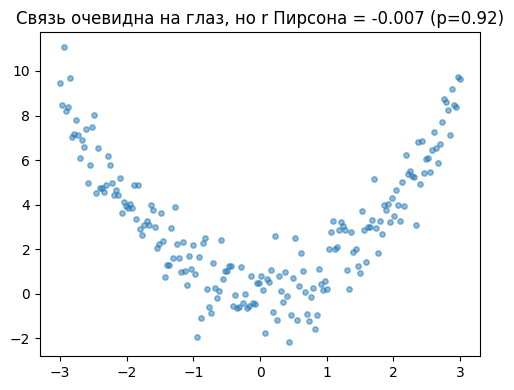

Коэффициент корреляции почти не видит эту явную квадратичную зависимость, потому что ищет только линейную связь.


In [43]:
# 13.1
np.random.seed(5)
x_curve = np.linspace(-3, 3, 200)
y_curve = x_curve**2 + np.random.normal(0, 1, 200)   # явная параболическая связь

r_pearson, p_pearson = stats.pearsonr(x_curve, y_curve)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x_curve, y_curve, alpha=0.5, s=15)
ax.set_title(f"Связь очевидна на глаз, но r Пирсона = {r_pearson:.3f} (p={p_pearson:.2f})")
plt.tight_layout()
plt.show()
print("Коэффициент корреляции почти не видит эту явную квадратичную зависимость, потому что ищет только линейную связь.")

Теперь обычный случай — линейная связь с шумом: считаем все три коэффициента корреляции и строим регрессию.

Pearson:  r = 0.826, p = 1.28e-38
Spearman: r = 0.803, p = 4.46e-35
Kendall:  τ = 0.609, p = 2.16e-28


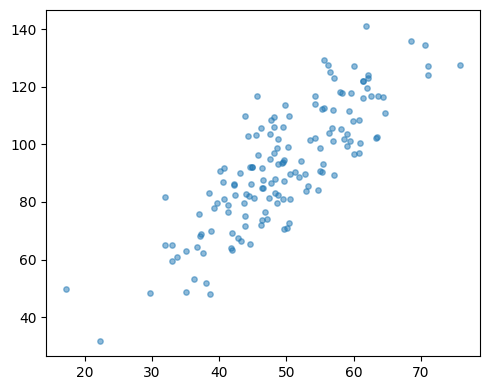

In [44]:
# 13.2
n = 150
x = np.random.normal(50, 10, n)
y = 3.0 + 1.8 * x + np.random.normal(0, 12, n)   # y = beta0 + beta1*x + шум

r_p, p_p = stats.pearsonr(x, y)
r_s, p_s = stats.spearmanr(x, y)
r_k, p_k = stats.kendalltau(x, y)

print(f"Pearson:  r = {r_p:.3f}, p = {p_p:.2e}")
print(f"Spearman: r = {r_s:.3f}, p = {p_s:.2e}")
print(f"Kendall:  τ = {r_k:.3f}, p = {p_k:.2e}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x, y, alpha=0.5, s=15)
plt.tight_layout()
plt.show()

**Линейная регрессия (один предиктор).** Если корреляция подтвердила связь, строим модель, чтобы предсказывать Y по X:

$$y = \beta_0 + \beta_1 x + \varepsilon$$

- $\beta_0$ (intercept) — значение Y, когда X = 0;
- $\beta_1$ — угол наклона регрессионной прямой: на сколько изменится Y при росте X на единицу;
- $\varepsilon$ — ошибка (остатки уравнения регрессии).

**Метод наименьших квадратов (OLS)** находит «лучшую» линию, балансируя ошибки — минимизирует сумму квадратов ошибок от регрессионной прямой. Выбирает $\beta_0$ и $\beta_1$ так, чтобы минимизировать:

$$\sum_i (y_i - \hat{y}_i)^2$$

In [45]:
# 13.3
import statsmodels.api as sm

model = sm.OLS(y, sm.add_constant(x)).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     317.0
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           1.28e-38
Time:                        04:55:24   Log-Likelihood:                -582.97
No. Observations:                 150   AIC:                             1170.
Df Residuals:                     148   BIC:                             1176.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4040      5.045      0.873      0.3

**Проверка гипотез в регрессии.** Для $\beta_1$: H₀: $\beta_1 = 0$ (X не влияет на Y), H₁: $\beta_1 \neq 0$. p-value показывает значимость связи. Это тот же t-тест (раздел 1) — только теперь он проверяет коэффициент регрессии, а не разницу средних. Заметьте также F-статистику в выводе выше — это F-критерий (раздел 2), проверяющий модель в целом.

**Коэффициент детерминации R²** — сколько % вариации Y объясняет модель. Диапазон 0-1, показывает «качество» модели:

$$R^2 = 1 - \frac{SSE}{SST}$$

где SSE — сумма квадратов остатков, SST — общая сумма квадратов (отклонение каждого наблюдения от среднего по Y, в квадрате, просуммированное).

beta0 = 4.40, beta1 = 1.78, p-value(beta1) = 1.28e-38
R^2 (вручную) = 0.682, R^2 (statsmodels) = 0.682


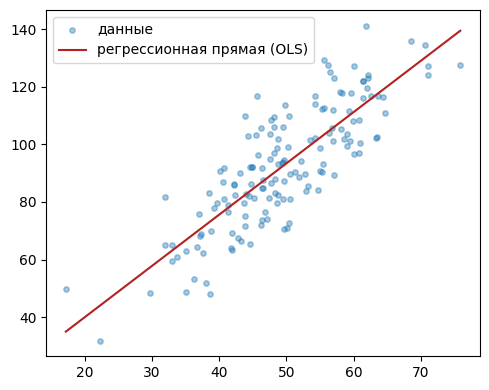

In [46]:
# 13.4
beta0, beta1 = model.params
pval_beta1 = model.pvalues[1]

y_pred = model.predict(sm.add_constant(x))
sse = np.sum((y - y_pred) ** 2)
sst = np.sum((y - y.mean()) ** 2)
r2_manual = 1 - sse / sst

print(f"beta0 = {beta0:.2f}, beta1 = {beta1:.2f}, p-value(beta1) = {pval_beta1:.2e}")
print(f"R^2 (вручную) = {r2_manual:.3f}, R^2 (statsmodels) = {model.rsquared:.3f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x, y, alpha=0.4, s=15, label="данные")
order = np.argsort(x)
ax.plot(x[order], y_pred[order], color="firebrick", label="регрессионная прямая (OLS)")
ax.legend()
plt.tight_layout()
plt.show()

## 14. Множественные предикторы

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n + \varepsilon$$

**Мультиколлинеарность** — высокая корреляция между предикторами. При мультиколлинеарности стандартные ошибки коэффициентов линейной регрессии искусственно завышаются, что приводит к увеличению вероятности ошибки 2 рода. Мультиколлинеарность не влияет на сами значения коэффициентов регрессии — только на их стандартные ошибки.

**Фактор инфляции дисперсии (VIF)**:

$$VIF_i = \frac{1}{1 - R_i^2}$$

где $R_i^2$ — коэффициент детерминации от регрессии предиктора $i$ на все остальные предикторы. Высокие значения VIF могут означать высокую коллинеарность данной переменной с остальными. Решение об удалении переменной на основании VIF следует принимать исходя из контекста задачи.

**Выбор лучшей модели.** Обычный R² в случае множественной регрессии менее адекватен, так как он растёт вне зависимости от качества независимых переменных в модели, поэтому применяется исправленный R² (adjusted R²) — он острее реагирует на бесполезные независимые переменные, и при их добавлении adjusted R² снижается.

**Подходы к отбору переменных: forward selection, backward elimination, regularization (Lasso, Ridge).**

- *Forward / backward selection* — добавляют или убирают предикторы по одному, ориентируясь на изменение adjusted R² или похожих критериев (AIC/BIC).
- *Ridge regression* — добавляет к функции потерь штраф на сумму квадратов коэффициентов ($\lambda\sum\beta_i^2$). Не обнуляет коэффициенты, а «сжимает» их к нулю — особенно сильно у коллинеарных предикторов, которые без регуляризации получили бы неустойчивые, раздутые оценки.
- *Lasso regression* — штраф на сумму МОДУЛЕЙ коэффициентов ($\lambda\sum|\beta_i|$). В отличие от Ridge, может обнулить коэффициент полностью — то есть выполняет отбор признаков автоматически, как часть самой процедуры подгонки модели, а не отдельным алгоритмом до неё.

**Условия применения линейной регрессии**: связь линейна и монотонна, независимость наблюдений, остатки распределены нормальным образом, гомоскедастичность, нет сильной мультиколлинеарности (для multiple).

**Логистическая регрессия** — расширение классической линейной регрессии, заточенное под анализ связи независимой переменной и бинарной зависимой переменной.

**Кластеризация** выполняется с помощью кластерного анализа: наблюдения объединяют в группы по схожести в количественных переменных. Нужна, когда нет готовой разбивки на группы (подробный пайплайн — в разделе 30).

**VIF и мультиколлинеарность на практике.** Возьмём два независимых предиктора и один, который почти дублирует первый (сильно с ним коррелирует).

In [47]:
# 14.1
from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(9)
n = 200
x1 = np.random.normal(0, 1, n)
x2 = np.random.normal(0, 1, n)
x3 = x1 * 0.95 + np.random.normal(0, 0.1, n)   # почти дублирует x1

X = pd.DataFrame({"x1": x1, "x2": x2, "x3": x3})
X_const = sm.add_constant(X)

vif = pd.DataFrame({
    "предиктор": X_const.columns,
    "VIF": [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])],
})
vif

,предиктор,VIF
0,const,1.0000
1,x1,79.2113
2,x2,1.0408
3,x3,79.3700


VIF у x1 и x3 сильно завышен — они несут почти одну и ту же информацию. Это не искажает сами коэффициенты, но раздувает их стандартные ошибки: посмотрим на модель с x3 и без.

In [48]:
# 14.2
y_target = 2 + 1.5 * x1 + 0.8 * x2 + np.random.normal(0, 1, n)

model_with_x3 = sm.OLS(y_target, sm.add_constant(X[["x1", "x2", "x3"]])).fit()
model_without_x3 = sm.OLS(y_target, sm.add_constant(X[["x1", "x2"]])).fit()

print("С коллинеарным x3:")
print(model_with_x3.params.round(3), "\nSE:", model_with_x3.bse.round(3))
print("\nБез x3:")
print(model_without_x3.params.round(3), "\nSE:", model_without_x3.bse.round(3))
print("\nКоэффициент при x1 похож в обеих моделях, но его стандартная ошибка заметно меньше без коллинеарного x3.")

С коллинеарным x3:
const    2.106
x1       0.929
x2       0.780
x3       0.456
dtype: float64 
SE: const    0.072
x1       0.629
x2       0.075
x3       0.669
dtype: float64

Без x3:
const    2.106
x1       1.355
x2       0.777
dtype: float64 
SE: const    0.072
x1       0.072
x2       0.074
dtype: float64

Коэффициент при x1 похож в обеих моделях, но его стандартная ошибка заметно меньше без коллинеарного x3.


**R² против adjusted R²** — добавим заведомо бесполезный (шумовой) предиктор и посмотрим, как реагирует каждая метрика.

In [49]:
# 14.3
noise_predictor = np.random.normal(0, 1, n)
X_with_noise = sm.add_constant(pd.DataFrame({"x1": x1, "x2": x2, "noise": noise_predictor}))
model_noise = sm.OLS(y_target, X_with_noise).fit()

print(f"Без шумового предиктора:  R^2 = {model_without_x3.rsquared:.4f}, adj. R^2 = {model_without_x3.rsquared_adj:.4f}")
print(f"С шумовым предиктором:    R^2 = {model_noise.rsquared:.4f}, adj. R^2 = {model_noise.rsquared_adj:.4f}")
print("\nR^2 почти не падает (а может даже немного вырасти) от добавления шума, adjusted R^2 — снижается.")

Без шумового предиктора:  R^2 = 0.6723, adj. R^2 = 0.6689
С шумовым предиктором:    R^2 = 0.6731, adj. R^2 = 0.6681

R^2 почти не падает (а может даже немного вырасти) от добавления шума, adjusted R^2 — снижается.


**Regularization: OLS vs Ridge vs Lasso.** 18 предикторов, из которых только 3 реально связаны с Y, остальные 15 — чистый шум. Посмотрим, что каждый метод делает с коэффициентами шумовых предикторов.

In [50]:
# 14.4
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

np.random.seed(15)
n_obs, n_useful, n_noise = 100, 3, 15
X_useful = np.random.normal(0, 1, (n_obs, n_useful))
X_noise = np.random.normal(0, 1, (n_obs, n_noise))
X_all = np.hstack([X_useful, X_noise])
true_coefs = np.array([2.0, -1.5, 1.0] + [0.0] * n_noise)
y_reg = X_all @ true_coefs + np.random.normal(0, 1, n_obs)

X_scaled = StandardScaler().fit_transform(X_all)
ols_fit = LinearRegression().fit(X_scaled, y_reg)
ridge_fit = Ridge(alpha=5.0).fit(X_scaled, y_reg)
lasso_fit = Lasso(alpha=0.3).fit(X_scaled, y_reg)

coef_compare = pd.DataFrame({
    "предиктор": [f"x{i+1}" for i in range(n_useful + n_noise)],
    "истинный коэфф.": true_coefs,
    "OLS": ols_fit.coef_.round(3),
    "Ridge": ridge_fit.coef_.round(3),
    "Lasso": lasso_fit.coef_.round(3),
})
print(coef_compare.to_string(index=False))
print(f"\nЧисло ненулевых коэффициентов: OLS = {(ols_fit.coef_ != 0).sum()}, Ridge = {(np.abs(ridge_fit.coef_) > 1e-6).sum()}, Lasso = {(np.abs(lasso_fit.coef_) > 1e-6).sum()} (из {n_useful} реальных)")
print("OLS даёт ненулевые (шумные) коэффициенты вообще всем предикторам. Lasso обнулил все 15 шумовых предикторов и оставил ровно те 3, что реально влияют на Y.")

предиктор  истинный коэфф.    OLS  Ridge  Lasso
       x1              2.0  1.970  1.838  1.621
       x2             -1.5 -1.515 -1.405 -1.107
       x3              1.0  0.914  0.848  0.531
       x4              0.0 -0.027 -0.019  0.000
       x5              0.0  0.102  0.089  0.000
       x6              0.0  0.002 -0.008 -0.000
       x7              0.0  0.173  0.134  0.000
       x8              0.0 -0.128 -0.101 -0.000
       x9              0.0 -0.024 -0.013  0.000
      x10              0.0  0.094  0.123  0.000
      x11              0.0  0.158  0.130  0.000
      x12              0.0  0.005 -0.004  0.000
      x13              0.0  0.004  0.016 -0.000
      x14              0.0  0.151  0.111  0.000
      x15              0.0 -0.144 -0.115  0.000
      x16              0.0 -0.094 -0.037  0.000
      x17              0.0 -0.292 -0.277 -0.000
      x18              0.0 -0.060 -0.076 -0.000

Число ненулевых коэффициентов: OLS = 18, Ridge = 18, Lasso = 3 (из 3 реальных)
OLS даёт

**Логистическая регрессия.** Пример из конспекта — поступление в вуз (`admit`, 0/1) по среднему баллу (`mark`). Смоделируем похожую ситуацию и оценим модель.

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  150
Model:                          Logit   Df Residuals:                      148
Method:                           MLE   Df Model:                            1
Date:                Fri, 18 Sep 2026   Pseudo R-squ.:                 0.09142
Time:                        04:55:25   Log-Likelihood:                -94.164
converged:                       True   LL-Null:                       -103.64
Covariance Type:            nonrobust   LLR p-value:                 1.343e-05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.6792      1.894     -4.055      0.000     -11.391      -3.967
x1             2.2303      0.556      4.014      0.000       1.141       3.319


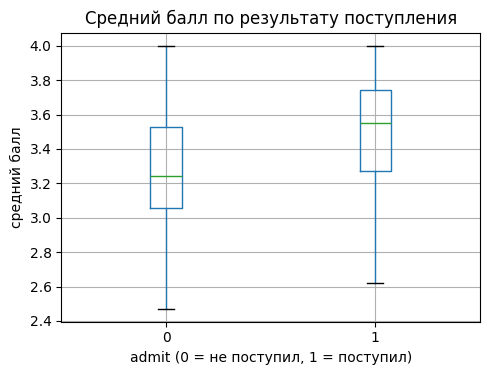

In [51]:
# 14.5
np.random.seed(13)
n_students = 150
mark = np.random.normal(3.4, 0.4, n_students).clip(2.0, 4.0)
logit_p = -6.5 + 1.9 * mark
p_admit = 1 / (1 + np.exp(-logit_p))
admit = np.random.binomial(1, p_admit)

logit_model = sm.Logit(admit, sm.add_constant(mark)).fit(disp=0)
print(logit_model.summary())

fig, ax = plt.subplots(figsize=(5, 4))
pd.DataFrame({"mark": mark, "admit": admit}).boxplot(column="mark", by="admit", ax=ax)
ax.set_xlabel("admit (0 = не поступил, 1 = поступил)")
ax.set_ylabel("средний балл")
plt.suptitle("")
ax.set_title("Средний балл по результату поступления")
plt.tight_layout()
plt.show()

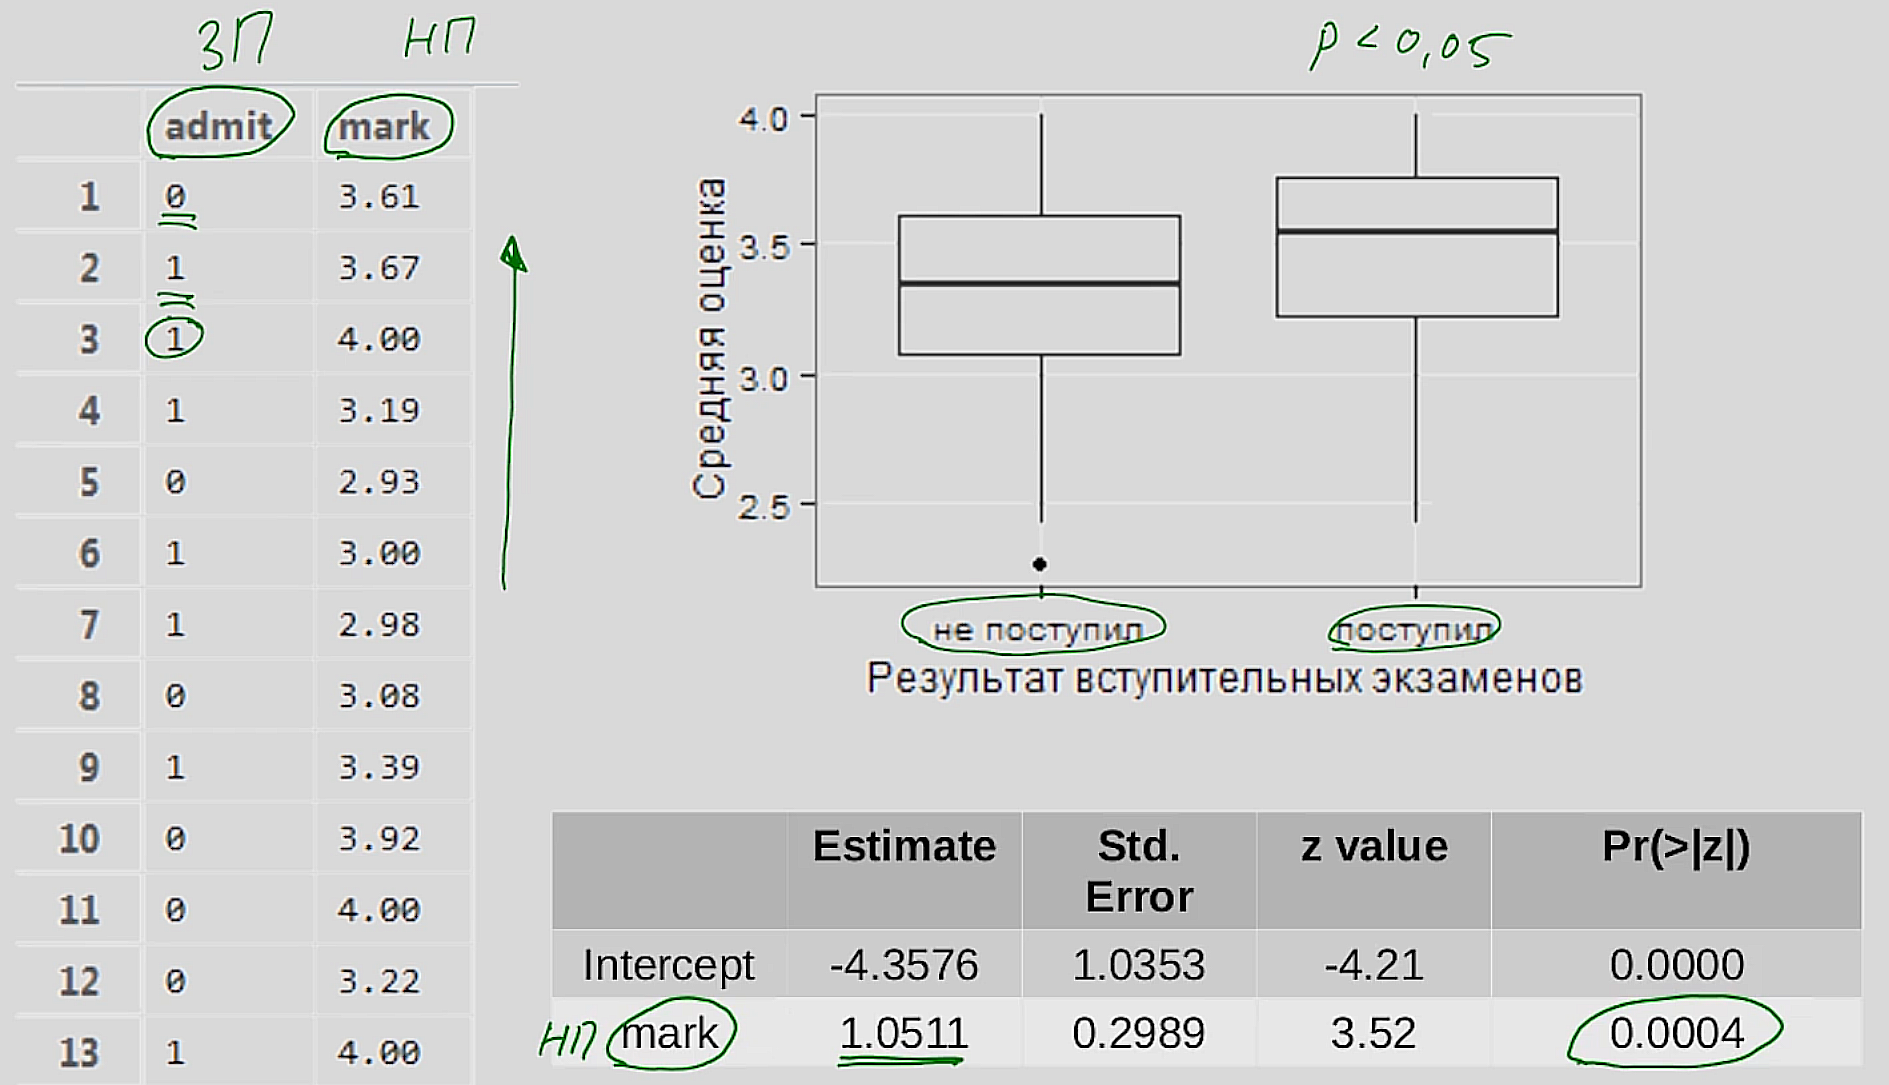

*Оригинальная иллюстрация из конспекта: логистическая регрессия admit ~ mark.*

## 15. Виды метрик

**1. Бинарные (конверсионные)** — отвечают на вопрос «произошло событие или нет?». Примеры: Retention, Churn Rate. Bernoulli-распределение, после агрегации — биномиальное. Полностью разобраны в разделе 3: биномиальное распределение, z-тест для пропорций, хи-квадрат.

`user-level данные → mean метрики → z-test для пропорций / хи-квадрат (раздел 3) → p-value + CI (раздел 4)`

**2. Аддитивные** — непрерывные и стоимостные метрики (средние метрики пользователей), обычно денежное выражение или измерение времени. Примеры: Average Check, Average Session Duration, ARPU. Heavy-tail распределение.

`event data → агрегация до user-level → (опц.) winsorization/trimming → (опц.) CUPED (раздел 20) → t-test (раздел 1) (при сильной скошенности — bootstrap, раздел 19)`

**3. Ratio-метрики (метрики отношения)** — когда числитель и знаменатель случайны, и считается их общее отношение по всей группе. Примеры: CTR, ARPPU, Orders per Session, Frequency.

`event data → user-level агрегация (clicks_i, impressions_i) → линеаризация (раздел 18) (опц. дельта-метод, раздел 22, или bootstrap, раздел 19) → (опц.) CUPED → t-test`

**4. Percentile-метрики** — p95 latency, p90 delivery time, p50 session duration.

`user-level данные → bootstrap (раздел 19) → перцентиль распределения → доверительный интервал → p-value`

**5. Метрики распределения** — отдельный класс, специально в конспекте не расписан.

In [52]:
# 15.1
metric_types = pd.DataFrame({
    "тип метрики": ["Бинарная (конверсионная)", "Аддитивная", "Ratio", "Percentile"],
    "примеры": ["Retention, Churn Rate", "Average Check, ARPU, Session Duration", "CTR, ARPPU, Orders/Session", "p95 latency, p50 duration"],
    "распределение": ["Bernoulli / биномиальное", "heavy-tail", "отношение случайных величин", "—"],
    "основной метод": ["z-test для пропорций / хи-квадрат (разд. 3)", "t-test (разд. 1), или bootstrap (разд. 19) при сильной скошенности", "линеаризация (разд. 18) (+ дельта-метод/bootstrap) -> t-test", "bootstrap (разд. 19)"],
})
metric_types

,тип метрики,примеры,распределение,основной метод
0,Бинарная (конверсионная),"Retention, Churn Rate",Bernoulli / биномиальное,z-test для пропорций / хи-квадрат (разд. 3)
1,Аддитивная,"Average Check, ARPU, Session Duration",heavy-tail,"t-test (разд. 1), или bootstrap (разд. 19) при..."
2,Ratio,"CTR, ARPPU, Orders/Session",отношение случайных величин,линеаризация (разд. 18) (+ дельта-метод/bootst...
3,Percentile,"p95 latency, p50 duration",—,bootstrap (разд. 19)


## 16. α, β, MDE, размер выборки

**α (альфа) — уровень значимости.** Вероятность ошибки I рода (ложно сказать, что эффект есть). Стандарт: α = 0.05 (5%), соответствует 95% доверительному интервалу (раздел 4).

**β (бета) и Power (мощность).** β — вероятность ошибки II рода (пропустить реальный эффект). Power = 1 − β — вероятность обнаружить эффект, если он действительно есть. Стандарт: Power = 80% → β = 0.20.

**MDE (Minimum Detectable Effect)** — минимальный эффект, который тест способен надёжно поймать при заданных α, β и размере выборки. Обозначается как δ (дельта).

**Размер выборки** (n на одну группу):

$$n = \frac{2\sigma^2(z_{1-\alpha/2} + z_{1-\beta})^2}{\delta^2}$$

**MDE — три подхода к выбору**

*Подход 1. От экономики (ROI и здравый смысл).* Любая фича стоит денег (разработка, поддержка, серверы) и должна себя окупить. Считаем точку безубыточности: если для окупаемости фичи конверсия должна вырасти минимум на 2%, то MDE = 2%. Тест, показавший статистически значимый, но меньший эффект — для бизнеса всё равно провал.

*Подход 2. Эмпирический (по историческим данным).* Смотрим на результаты десятков предыдущих А/Б-тестов в этой же части продукта и оцениваем масштаб «реалистичных» изменений. MDE выбирается по нижней границе реалистичных успешных кейсов в этой доменной зоне — иначе тест обречён на «не прокрасилось».

*Подход 3. «От обратного» (ресурсный / от трафика).* Самый частый сценарий на практике: нет бесконечного времени на тест, трафик нужен и для других тестов. Жёстко фиксируем время теста и доступный трафик, затем смотрим, какой MDE вообще можем себе позволить с таким трафиком. Если реалистично ожидаемый эффект намного меньше достижимого MDE — тест запускать бессмысленно, он гарантированно ничего не найдёт. Нужно либо отказаться от теста, либо применить CUPED/стратификацию, либо копить трафик дольше.

**Откуда берётся σ на практике.** Формула размера выборки предполагает, что σ уже известна — но на практике её ещё нужно откуда-то взять:
1. Из пилотных данных или истории той же метрики за похожий период — самый надёжный вариант, если такая история есть.
2. Из похожего, но не идентичного прошлого теста — как proxy, с поправкой на то, что это приближение.
3. Если истории вообще нет и метрика — пропорция (конверсия), можно взять консервативную оценку p=0.5: величина p(1-p) максимальна именно при p=0.5, поэтому такая оценка гарантированно не занизит нужный размер выборки (хотя и может сильно завысить его, если истинная конверсия далека от 50%).
4. В крайнем случае — условные ("на глаз") ориентиры вроде эффектов Коэна (small/medium/large: d≈0.2/0.5/0.8) — это не замена реальным данным, а последний резерв.

Важно: слишком старые исторические данные рискованны — дисперсия метрики могла измениться (сезонность, изменения в продукте), поэтому оценку стоит периодически перепроверять.

In [53]:
# 16.1
from statsmodels.stats.power import TTestIndPower

alpha = 0.05
power_target = 0.80
sigma = 20.0     # историческое std метрики
mde = 5.0        # минимальный эффект, который хотим ловить

z_alpha = stats.norm.ppf(1 - alpha / 2)
z_beta = stats.norm.ppf(power_target)

n_formula = 2 * sigma**2 * (z_alpha + z_beta)**2 / mde**2
print(f"По формуле из конспекта: n ≈ {np.ceil(n_formula):.0f} человек на группу")

effect_size = mde / sigma
n_statsmodels = TTestIndPower().solve_power(effect_size=effect_size, alpha=alpha, power=power_target, ratio=1.0)
print(f"Проверка через statsmodels (TTestIndPower): n ≈ {np.ceil(n_statsmodels):.0f} человек на группу")

По формуле из конспекта: n ≈ 252 человек на группу
Проверка через statsmodels (TTestIndPower): n ≈ 253 человек на группу


**MDE «от трафика» (подход 3)** — если известно, сколько пользователей реально доступно за отведённое время теста, какой MDE мы вообще можем себе позволить?

In [54]:
# 16.2
n_available_per_group = 1200   # столько трафика реально есть за 2 недели на группу

mde_achievable = np.sqrt(2 * sigma**2 * (z_alpha + z_beta)**2 / n_available_per_group)
print(f"При {n_available_per_group} пользователях на группу достижимый MDE ≈ {mde_achievable:.2f} (в тех же единицах, что и метрика)")
print("Если реалистично ожидаемый эффект намного меньше — тест с таким трафиком проводить не имеет смысла.")

При 1200 пользователях на группу достижимый MDE ≈ 2.29 (в тех же единицах, что и метрика)
Если реалистично ожидаемый эффект намного меньше — тест с таким трафиком проводить не имеет смысла.


**Чувствительность размера выборки к качеству оценки σ.** Ошиблись в оценке σ (например, взяли устаревшие исторические данные) — ошиблись и в нужном размере выборки.

In [55]:
# 16.3
for label, sigma_guess in [("верная оценка", 20), ("недооценили (устаревшие данные)", 14), ("переоценили (излишний запас)", 28)]:
    n = 2 * sigma_guess**2 * (z_alpha + z_beta)**2 / mde**2
    print(f"{label:35s}: sigma={sigma_guess} -> n ≈ {np.ceil(n):.0f} на группу")

верная оценка                      : sigma=20 -> n ≈ 252 на группу
недооценили (устаревшие данные)    : sigma=14 -> n ≈ 124 на группу
переоценили (излишний запас)       : sigma=28 -> n ≈ 493 на группу


**Почему p=0.5 — консервативная оценка для пропорций.** При фиксированном абсолютном MDE в процентных пунктах величина $p(1-p)$ (а вместе с ней и нужный размер выборки) максимальна ровно при p=0.5.

In [56]:
# 16.4
mde_p = 0.02  # 2 процентных пункта
for p_guess in [0.5, 0.3, 0.1, 0.02]:
    var_p = p_guess * (1 - p_guess)
    n_p = 2 * var_p * (z_alpha + z_beta)**2 / mde_p**2
    print(f"p={p_guess:<5} p(1-p)={var_p:.4f} -> n ≈ {np.ceil(n_p):.0f} на группу")
print("\nЧем ближе предполагаемая база к 0.5, тем больше требуемый размер выборки -- поэтому p=0.5 безопасна как оценка 'на всякий случай'.")

p=0.5   p(1-p)=0.2500 -> n ≈ 9812 на группу
p=0.3   p(1-p)=0.2100 -> n ≈ 8242 на группу
p=0.1   p(1-p)=0.0900 -> n ≈ 3532 на группу
p=0.02  p(1-p)=0.0196 -> n ≈ 770 на группу

Чем ближе предполагаемая база к 0.5, тем больше требуемый размер выборки -- поэтому p=0.5 безопасна как оценка 'на всякий случай'.


## 17. Бакеты

Бакетирование — техника, при которой каждому пользователю стабильно присваивается номер (бакет), а эксперименты управляют группами этих номеров, а не отдельными пользователями.

```
bucket = hash(user_id + соль) % 10000
```

**Плюсы**
- стабильность — пользователь не прыгает между группами A/B во время эксперимента;
- хорошая изоляция экспериментов друг от друга (особенно с солью и слоями);
- легко управлять большим количеством параллельных экспериментов;
- детерминированность — один и тот же пользователь всегда в одном и том же варианте (удобно для анализа);
- легко включать/выключать эксперимент — просто меняешь диапазон бакетов;
- можно анализировать данные даже после завершения эксперимента.

**Минусы**
- сложность реализации — нужно правильно реализовать хеширование, соль, слои;
- неидеальное равенство групп — при небольшом количестве бакетов группы могут быть немного неравными;
- проблема холодных пользователей — если пользователь неактивен, он всё равно занимает бакет (но это проблема всех методов);
- сложнее делать очень маленькие эксперименты (например, 1% трафика) — нужно аккуратно выбирать диапазоны;
- требует дисциплины в управлении солями и слоями (иначе появляются пересечения).

user_42 дважды: 9696 9696


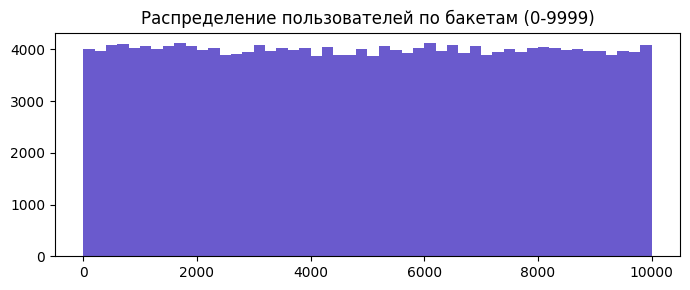


В эксперимент попало: 10.1% пользователей (ожидали 10%)
Из них в группе A: 49.7%, в группе B: 50.3%


In [57]:
# 17.1
import hashlib

def bucket(user_id, salt, n_buckets=10_000):
    key = f"{user_id}_{salt}".encode()
    return int(hashlib.md5(key).hexdigest(), 16) % n_buckets

# детерминированность: один и тот же user_id + соль всегда даёт один и тот же бакет
print("user_42 дважды:", bucket("user_42", "exp_button_color"), bucket("user_42", "exp_button_color"))

# распределение по бакетам должно быть примерно равномерным
user_ids = [f"user_{i}" for i in range(200_000)]
buckets = np.array([bucket(uid, "exp_button_color") for uid in user_ids])

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(buckets, bins=50, color="slateblue")
ax.set_title("Распределение пользователей по бакетам (0-9999)")
plt.tight_layout()
plt.show()

# выделяем 10% трафика под эксперимент диапазоном бакетов, и делим этот диапазон пополам на A/B
in_experiment = buckets < 1000                 # 10% трафика
group = np.where(buckets < 500, "A", "B")      # первая половина диапазона -> A, вторая -> B
print(f"\nВ эксперимент попало: {in_experiment.mean():.1%} пользователей (ожидали 10%)")
print(f"Из них в группе A: {(group[in_experiment] == 'A').mean():.1%}, в группе B: {(group[in_experiment] == 'B').mean():.1%}")

## 18. Линеаризация

**1. Цель.** Есть ratio-метрика: $CTR = \dfrac{\sum Y_i}{\sum X_i}$, где $Y_i$ — клики пользователя, $X_i$ — показы пользователя. Нельзя применить t-test напрямую, потому что CTR группы — это одно число, а t-test требует распределение пользовательских значений. Линеаризация строит пользовательскую метрику:

$$L_i = Y_i - R_0 \cdot X_i$$

**2. Откуда берётся $R_0$?** Это базовое значение ratio-метрики, относительно которого делается разложение. Обычно берут $R_0 = CTR_{control} = \dfrac{\sum Y_{i,control}}{\sum X_{i,control}}$.

**3. Контрольная группа** линеаризуется тем же самым $R_0$: $L_{i,control} = Y_{i,control} - R_0 \cdot X_{i,control}$, аналогично для теста: $L_{i,test} = Y_{i,test} - R_0 \cdot X_{i,test}$.

**4. Почему нельзя взять свой R для каждой группы?** Тогда бы сравнивались две разные метрики — как контроль в метрах, а тест в футах. t-test в таком случае теряет смысл.

**5. Почему именно контроль — baseline?** Гипотеза A/B теста: $H_0: CTR_{test} = CTR_{control}$. Контроль — точка отсчёта, интересует, насколько тест отклоняется от поведения, характерного для контроля.

**6. Что происходит с контролем после линеаризации?** $E[L_{control}] = E[Y - R_0 X]$. Так как $R_0 = E[Y]/E[X]$, то $E[L_{control}] \approx 0$ — контроль центрируется около нуля.

**7. Что будет с тестом?** Если эффекта нет — $E[L_{test}] \approx 0$. Если CTR изменился — $E[L_{test}] \neq 0$, и t-test обнаружит различия.

**8. Полный алгоритм**
1. Считаем CTR контроля: $R_0 = \sum Y_{control} / \sum X_{control}$.
2. Линеаризуем контроль: $L_{i,control} = Y_{i,control} - R_0 X_{i,control}$.
3. Линеаризуем тест: $L_{i,test} = Y_{i,test} - R_0 X_{i,test}$.
4. Проводим t-test (раздел 1) на $L_{control}$ против $L_{test}$.

**9. Маленький пример.** Baseline $CTR_0 = 0.1$. У пользователя impressions = 10, clicks = 2. Ожидаемые клики: $0.1 \times 10 = 1$. Линеаризация: $L = 2 - 1 = 1$ — пользователь дал на 1 клик больше ожидаемого.

In [58]:
# 18.1
# маленький пример из конспекта, дословно
R0_example = 0.1
impressions_example = 10
clicks_example = 2
expected_clicks = R0_example * impressions_example
L_example = clicks_example - expected_clicks
print(f"Ожидаемые клики = {R0_example} * {impressions_example} = {expected_clicks}")
print(f"L = {clicks_example} - {expected_clicks} = {L_example}  (пользователь сверх ожидания дал +{L_example:.0f} клик)")

Ожидаемые клики = 0.1 * 10 = 1.0
L = 2 - 1.0 = 1.0  (пользователь сверх ожидания дал +1 клик)


Полный пример на уровне групп: у test и control разное число показов на пользователя, и в test реальный CTR немного выше.

In [59]:
# 18.2
np.random.seed(17)
n_users = 800

impressions_control = np.random.randint(20, 80, n_users)
clicks_control = np.random.binomial(impressions_control, 0.10)   # истинный CTR control = 10%

impressions_test = np.random.randint(20, 80, n_users)
clicks_test = np.random.binomial(impressions_test, 0.12)         # истинный CTR test = 12%

ctr_control_naive = clicks_control.sum() / impressions_control.sum()
ctr_test_naive = clicks_test.sum() / impressions_test.sum()
print(f"CTR control (групповой) = {ctr_control_naive:.4f}")
print(f"CTR test (групповой)    = {ctr_test_naive:.4f}")
print("Это одно число на группу — напрямую t-test на этом не построить.\n")

# Шаг 1: R0 по контролю
R0 = ctr_control_naive

# Шаги 2-3: линеаризация
L_control = clicks_control - R0 * impressions_control
L_test = clicks_test - R0 * impressions_test
print(f"Среднее L в контроле: {L_control.mean():.4f}  (ожидаемо ~0)")
print(f"Среднее L в тесте:    {L_test.mean():.4f}")

# Шаг 4: t-test на линеаризованной метрике
t_stat, p_val = stats.ttest_ind(L_test, L_control)
print(f"\nt-test на линеаризованной метрике: t = {t_stat:.2f}, p = {p_val:.4f}")
print(f"-> {'значимое отличие CTR' if p_val < 0.05 else 'значимого отличия не обнаружено'}")

CTR control (групповой) = 0.0996
CTR test (групповой)    = 0.1180
Это одно число на группу — напрямую t-test на этом не построить.

Среднее L в контроле: 0.0000  (ожидаемо ~0)
Среднее L в тесте:    0.9136

t-test на линеаризованной метрике: t = 8.15, p = 0.0000
-> значимое отличие CTR


## 19. Bootstrap

Бутстрап — статистический метод, который позволяет оценивать распределение статистики (например, среднего, медианы, коэффициента корреляции) с помощью переподборки данных с возвращением из исходной выборки.

**Плюсы**
1. Гибкость и универсальность — не требует аналитических производных и разложений, подходит для самых разных метрик и распределений, включая ratio-метрики, где классические формулы вариации применять сложно.
2. Интуитивность — если есть данные на уровне пользователя, можно переизвлекать их и считать метрику заново, пока не получится эмпирическое распределение оценок.
3. Не нужно дельта-метода или линеаризации — вместо формул через производные бутстрэп «даёт данным самим сказать» о своей дисперсии.
4. Применимость к сложным распределениям — многомодальным или сильно скошенным.

**Минусы**
1. Высокая вычислительная стоимость (нивелируется в Poisson bootstrap) — требует сотен/тысяч переизвлечений.
2. Зависимость от качества и репрезентативности выборки — при небольшой или смещённой выборке результаты могут быть неустойчивыми.
3. Чувствительность к выбросам и неоднородности данных.
4. Нет «магического» решения для очень малых выборок.

**Poisson bootstrap.** Главное отличие от обычного бутстрапа — способ формирования подвыборок: вместо реального извлечения элементов с возвращением используется математическая аппроксимация через распределение Пуассона.

| | Обычный Bootstrap | Poisson Bootstrap |
|---|---|---|
| Механизм | Сэмплирование N элементов с возвращением | Вес из Pois(1) для каждого наблюдения |
| Сложность | Высокая на больших данных | Низкая (эффективнее) |
| Применение | Малые и средние выборки | Big Data, A/B-тесты в продакшене (например, PySpark) |
| Результат | Точный (согласно методу) | Асимптотически эквивалентный |

При больших N количество попаданий конкретного элемента в обычную бутстрап-выборку распределено по биномиальному закону Bin(N, 1/N), которое по предельной теореме стремится к Pois(1) — поэтому Poisson Bootstrap асимптотически эквивалентен классическому, но вычислительно эффективнее (не требует перемешивания данных, только арифметику с весами — отсюда и выигрыш в распределённых системах).

Точечная оценка среднего: 294.6
Классический bootstrap: 95% ДИ = [281.5, 307.6]
Poisson bootstrap:      95% ДИ = [281.9, 307.8]

Оба метода дают практически одинаковый результат — Poisson bootstrap асимптотически эквивалентен классическому.
Его выигрыш в скорости проявляется в первую очередь в распределённых системах (например, PySpark), где не нужно физически
перемешивать и переиндексировать данные между узлами — достаточно назначить вес каждому наблюдению.


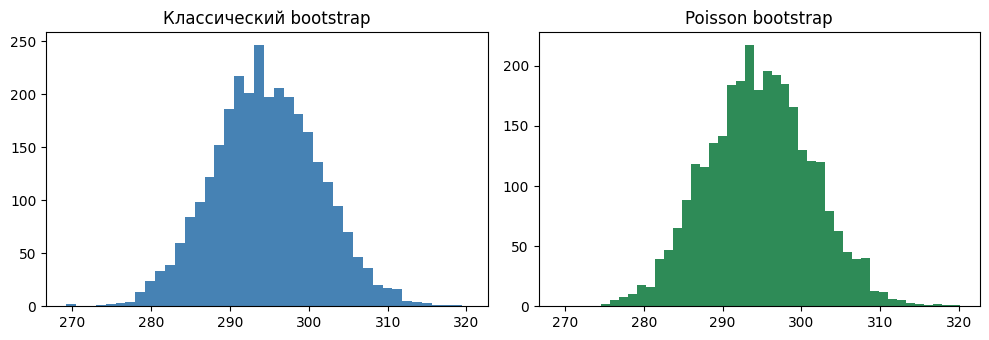

In [60]:
# 19.1
np.random.seed(19)
revenue = np.random.exponential(300, 2000)   # скошенная метрика (например, чек)
n = len(revenue)
n_boot = 3000

lower_pct, upper_pct = 2.5, 97.5

# --- классический bootstrap (векторизованно) ---
idx = np.random.randint(0, n, size=(n_boot, n))
boot_means_classic = revenue[idx].mean(axis=1)
ci_classic = np.percentile(boot_means_classic, [lower_pct, upper_pct])

# --- Poisson bootstrap (векторизованно) ---
weights = np.random.poisson(1, size=(n_boot, n))
boot_means_poisson = (revenue[None, :] * weights).sum(axis=1) / weights.sum(axis=1)
ci_poisson = np.percentile(boot_means_poisson, [lower_pct, upper_pct])

print(f"Точечная оценка среднего: {revenue.mean():.1f}")
print(f"Классический bootstrap: 95% ДИ = [{ci_classic[0]:.1f}, {ci_classic[1]:.1f}]")
print(f"Poisson bootstrap:      95% ДИ = [{ci_poisson[0]:.1f}, {ci_poisson[1]:.1f}]")
print("\nОба метода дают практически одинаковый результат — Poisson bootstrap асимптотически эквивалентен классическому.")
print("Его выигрыш в скорости проявляется в первую очередь в распределённых системах (например, PySpark), где не нужно физически")
print("перемешивать и переиндексировать данные между узлами — достаточно назначить вес каждому наблюдению.")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True)
axes[0].hist(boot_means_classic, bins=40, color="steelblue")
axes[0].set_title("Классический bootstrap")
axes[1].hist(boot_means_poisson, bins=40, color="seagreen")
axes[1].set_title("Poisson bootstrap")
plt.tight_layout()
plt.show()

## 20. CUPED

CUPED (*Controlled-experiment Using Pre-Experiment Data*) — статистический метод для повышения чувствительности A/B-тестов (снижения дисперсии) за счёт использования данных о поведении пользователей до начала эксперимента. Позволяет получить более точные результаты при меньшем размере выборки или сократить время проведения теста.

**Главная идея.** Метрики часто «шумные» из-за индивидуальных различий пользователей. CUPED использует тот факт, что поведение пользователя в прошлом (например, выручка или время на сайте) хорошо предсказывает его поведение в будущем. Метод объясняет часть разброса метрики с помощью исторических данных и вычитает предсказуемую «шумную» составляющую.

**Формула.** Скорректированное значение метрики для каждого пользователя:

$$Y_{cuped,i} = Y_i - \theta (X_i - \bar{X})$$

Коэффициент $\theta$ подбирается так, чтобы минимизировать дисперсию результирующей метрики. В классическом виде:

$$\theta = \frac{\text{Cov}(X, Y)}{\text{Var}(X)}$$

**Свойства и преимущества**
- **Несмещённость**: $E[Y_{cuped}] = E[Y]$ — метод не искажает результаты, только делает их точнее (сужает доверительные интервалы).
- **Гибкость**: в качестве ковариаты X можно использовать не только аналогичную метрику за прошлый период, но и другие предэкспериментальные данные (пол, возраст, частота входов).
- **Универсальность**: применим практически к любым метрикам (конверсии, средний чек, время на сайте).

**Требования и ограничения**
1. Корреляция: X должен быть достаточно сильно скоррелирован с Y — чем выше корреляция, тем сильнее эффект от CUPED.
2. Независимость ковариаты: эксперимент не должен влиять на X, поэтому X берётся только за период до старта теста.
3. Для ratio-метрик (например, среднего чека, где меняется и число покупок, и их сумма) применение требует более сложных модификаций, таких как дельта-метод (раздел 22).

**Где считать θ: та же ловушка, что и с любой оценкой параметра по тем же данным, что идут в тест.** Формально θ можно оценить прямо на данных эксперимента (как в примере ниже) — при простом аддитивном эффекте это не смещает саму оценку среднего. Но у такой оценки θ есть слабое место: она подгоняется под шум именно этой конкретной выборки и поэтому выглядит оптимистичнее (даёт чуть меньшую дисперсию) именно на тех данных, на которых её оценили — а не обязательно на новых. Это тот же принцип, что overfitting в ML: оценка параметра и проверка гипотезы на одних и тех же данных требуют аккуратности. На практике из-за этого θ часто предпочитают считать один раз на большой стабильной исторической выборке (или на отдельном периоде до эксперимента) и переиспользовать, а не оценивать заново по каждому маленькому тесту.

Смоделируем ситуацию: у каждого пользователя есть исторические данные (выручка за прошлый период) и текущие данные (выручка за период теста), заметно коррелирующие между собой. В test-группе заложен реальный эффект.

In [61]:
# 20.1
np.random.seed(23)
n_per_group = 500

X_control = np.random.gamma(5, 40, n_per_group)             # выручка за прошлый период (ковариата)
Y_control = 0.9 * X_control + np.random.normal(0, 30, n_per_group) + 10   # текущая выручка, без эффекта

X_test = np.random.gamma(5, 40, n_per_group)
true_effect = 15
Y_test = 0.9 * X_test + np.random.normal(0, 30, n_per_group) + 10 + true_effect   # + реальный эффект теста

X_all, Y_all = np.r_[X_control, X_test], np.r_[Y_control, Y_test]
theta = np.cov(X_all, Y_all, ddof=1)[0, 1] / np.var(X_all, ddof=1)
X_bar = X_all.mean()

Y_cuped_control = Y_control - theta * (X_control - X_bar)
Y_cuped_test = Y_test - theta * (X_test - X_bar)

print(f"theta = {theta:.3f}  (корреляция X,Y = {np.corrcoef(X_all, Y_all)[0,1]:.2f})")
print()
print(f"Среднее Y control:        {Y_control.mean():8.2f}   Y_cuped control: {Y_cuped_control.mean():8.2f}   (несмещённость: среднее почти не сдвинулось)")
print(f"Среднее Y test:           {Y_test.mean():8.2f}   Y_cuped test:    {Y_cuped_test.mean():8.2f}")
print()
print(f"Дисперсия Y control:       {Y_control.var(ddof=1):8.1f}")
print(f"Дисперсия Y_cuped control: {Y_cuped_control.var(ddof=1):8.1f}   (заметно ниже — это и есть снижение шума)")

t_before, p_before = stats.ttest_ind(Y_test, Y_control)
t_after, p_after = stats.ttest_ind(Y_cuped_test, Y_cuped_control)
print(f"\nt-test на исходной метрике:  t = {t_before:.2f}, p = {p_before:.2e}")
print(f"t-test на CUPED-метрике:     t = {t_after:.2f}, p = {p_after:.2e}")
print("Эффект тот же самый, но за счёт снижения дисперсии CUPED-версия обнаруживает его увереннее (t-статистика выше).")

theta = 0.918  (корреляция X,Y = 0.93)

Среднее Y control:          182.05   Y_cuped control:   187.39   (несмещённость: среднее почти не сдвинулось)
Среднее Y test:             206.18   Y_cuped test:      200.83

Дисперсия Y control:         6826.1
Дисперсия Y_cuped control:    969.8   (заметно ниже — это и есть снижение шума)

t-test на исходной метрике:  t = 4.43, p = 1.04e-05
t-test на CUPED-метрике:     t = 6.97, p = 5.62e-12
Эффект тот же самый, но за счёт снижения дисперсии CUPED-версия обнаруживает его увереннее (t-статистика выше).


**θ «в моменте» против θ по большой исторической выборке.** Повторим маленький тест (n=150 на группу) много раз: один раз пересчитывая θ заново на каждой реализации (in-sample), другой раз используя раз и навсегда посчитанную θ на отдельной большой исторической выборке.

In [62]:
# 20.2
X_hist = np.random.gamma(5, 40, 50_000)
Y_hist = 0.9 * X_hist + np.random.normal(0, 30, 50_000) + 10
theta_historical = np.cov(X_hist, Y_hist, ddof=1)[0, 1] / np.var(X_hist, ddof=1)

n_repeats = 500
thetas_insample, var_insample, var_hist_theta = [], [], []
for _ in range(n_repeats):
    X_c = np.random.gamma(5, 40, 150)
    Y_c = 0.9 * X_c + np.random.normal(0, 30, 150) + 10
    theta_in = np.cov(X_c, Y_c, ddof=1)[0, 1] / np.var(X_c, ddof=1)
    thetas_insample.append(theta_in)
    var_insample.append((Y_c - theta_in * (X_c - X_c.mean())).var(ddof=1))
    var_hist_theta.append((Y_c - theta_historical * (X_c - X_c.mean())).var(ddof=1))

print(f"theta по большой истории (фиксированная): {theta_historical:.4f}")
print(f"theta, пересчитанная заново на каждой маленькой реализации: среднее {np.mean(thetas_insample):.4f}, std {np.std(thetas_insample):.4f}")
print(f"\nСредняя дисперсия CUPED-метрики: in-sample theta = {np.mean(var_insample):.1f}, историческая theta = {np.mean(var_hist_theta):.1f}")
print("In-sample оценка выглядит чуть 'лучше' именно на тех же данных, на которых её подобрали -- ровно поэтому её оптимистичность")
print("настораживает: тест и подбор theta на одних и тех же данных -- тот же риск, что overfitting в ML.")

theta по большой истории (фиксированная): 0.8999
theta, пересчитанная заново на каждой маленькой реализации: среднее 0.8985, std 0.0269

Средняя дисперсия CUPED-метрики: in-sample theta = 892.4, историческая theta = 898.1
In-sample оценка выглядит чуть 'лучше' именно на тех же данных, на которых её подобрали -- ровно поэтому её оптимистичность
настораживает: тест и подбор theta на одних и тех же данных -- тот же риск, что overfitting в ML.


## 21. Стратификация

Стратификация — метод разделения генеральной совокупности на однородные группы (страты) по какому-то признаку (ковариате) перед делением пользователей на контрольную и тестовую группы.

**Главная цель**: сделать тестовую и контрольную группы максимально похожими друг на друга по важным свойствам, уменьшив дисперсию («шум») и увеличив чувствительность (power) теста.

**Зачем это нужно.** В стандартном А/Б-тесте группы делятся случайно. Из-за случайности может возникнуть дисбаланс: например, в тестовую группу случайно попадёт больше «китов» или пользователей iOS, чем в контрольную. Это приведёт к высокой дисперсии и искажению результатов. Стратификация гарантирует, что пропорции ключевых сегментов в тесте и контроле будут строго идентичны.

**Два подхода**

1. *Пропорциональная стратификация* (на этапе сплитования) — выборка формируется так, чтобы доля каждой страты в эксперименте точно соответствовала её доле в генеральной совокупности. Минус: сложно реализовать инженерно в реальном времени, когда пользователи заходят постепенно и непредсказуемо.

2. *Пост-стратификация* (на этапе анализа результатов) — пользователи делятся случайно, а возможный дисбаланс «чинится» математически уже при подсчёте метрик: каждому пользователю присваивается вес, обратно пропорциональный размеру его страты в тесте/контроле.

**Математика: как уменьшается дисперсия.** Полная дисперсия метрики раскладывается на межгрупповую (разница средних между стратами) и внутригрупповую (естественный шум внутри страт):

$$\text{Полная дисперсия} = \text{Межгрупповая дисперсия} + \text{Внутригрупповая дисперсия}$$

Стратификация полностью обнуляет межгрупповую дисперсию в эксперименте — в t-test отправляется только чистый внутригрупповой шум, за счёт чего тест становится более чувствительным.

**Что выбирать в качестве страт**: должны быть сильно скоррелированы с целевой метрикой, но не зависеть от самого эксперимента.
- Хорошие страты: исторический доход пользователя, платформа (iOS/Android/Web), город/регион, версия ОС, уровень лояльности (дата регистрации).
- Плохие страты: любые метрики и действия, начавшие собираться или произошедшие после запуска А/Б-теста.

**Стратификация vs CUPED.** Стратификация использует дискретные признаки (или непрерывные, округлённые до категорий), применяется на этапе сплитования или анализа, хорошо работает при небольшой выборке и риске сильного дисбаланса. CUPED (раздел 20) предпочитает непрерывные исторические данные, применяется строго на этапе анализа, максимально эффективен на больших данных при высокой автокорреляции метрики. На практике их часто сочетают: сначала линеаризуют ratio-метрику (раздел 18), затем применяют CUPED по историческим данным, а остаточный шум дотюнивают пост-стратификацией по платформе или географии.

**Снижение дисперсии от стратификации.** Смоделируем метрику, которая заметно отличается между платформами (между-страты дисперсия), и сравним разброс оценки эффекта при случайном и при стратифицированном разбиении — при повторении эксперимента много раз.

Дисперсия оценки разницы, случайное разбиение:          7.23
Дисперсия оценки разницы, стратифицированное разбиение: 3.88
Снижение дисперсии: 46.3%


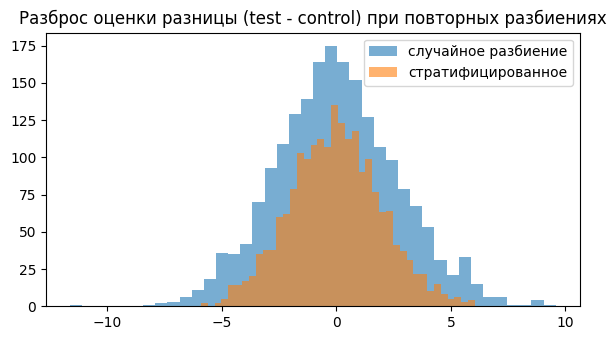

In [63]:
# 21.1
np.random.seed(29)
n_total = 1000
platform = np.random.choice(["iOS", "Android"], size=n_total, p=[0.4, 0.6])
metric = np.where(platform == "iOS", np.random.normal(150, 30, n_total), np.random.normal(90, 30, n_total))
# реального эффекта теста нет -- нас интересует только шум оценки разницы (должна колебаться около 0)

def random_split_diff():
    assign = np.random.randint(0, 2, n_total)
    return metric[assign == 1].mean() - metric[assign == 0].mean()

def stratified_split_diff():
    assign = np.empty(n_total, dtype=int)
    for p in np.unique(platform):
        idx = np.where(platform == p)[0]
        shuffled = np.random.permutation(idx)
        half = len(shuffled) // 2
        assign[shuffled[:half]] = 0
        assign[shuffled[half:]] = 1
    return metric[assign == 1].mean() - metric[assign == 0].mean()

n_repeats = 2000
random_diffs = np.array([random_split_diff() for _ in range(n_repeats)])
strat_diffs = np.array([stratified_split_diff() for _ in range(n_repeats)])

print(f"Дисперсия оценки разницы, случайное разбиение:          {random_diffs.var():.2f}")
print(f"Дисперсия оценки разницы, стратифицированное разбиение: {strat_diffs.var():.2f}")
print(f"Снижение дисперсии: {(1 - strat_diffs.var() / random_diffs.var()):.1%}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(random_diffs, bins=40, alpha=0.6, label="случайное разбиение")
ax.hist(strat_diffs, bins=40, alpha=0.6, label="стратифицированное")
ax.legend()
ax.set_title("Разброс оценки разницы (test - control) при повторных разбиениях")
plt.tight_layout()
plt.show()

**Пост-стратификация задним числом.** Один конкретный случайный сплит, где платформы случайно распределились неровно между группами — поправляем это взвешиванием по общей доле платформ, без переразбиения.

In [64]:
# 21.2
np.random.seed(19)
assign = np.random.randint(0, 2, n_total)
df_one_split = pd.DataFrame({"platform": platform, "metric": metric, "group": np.where(assign == 1, "test", "control")})

print("Доли платформ по группам (в идеале должны совпадать):")
print(df_one_split.groupby("group")["platform"].value_counts(normalize=True).unstack())

overall_share = df_one_split["platform"].value_counts(normalize=True)

def poststratified_mean(sub):
    stratum_means = sub.groupby("platform")["metric"].mean()
    return sum(overall_share[p] * stratum_means.get(p, 0) for p in overall_share.index)

naive_diff = (df_one_split.loc[df_one_split.group == "test", "metric"].mean()
              - df_one_split.loc[df_one_split.group == "control", "metric"].mean())
post_diff = (poststratified_mean(df_one_split[df_one_split.group == "test"])
             - poststratified_mean(df_one_split[df_one_split.group == "control"]))

print(f"\nНаивная разница средних (без поправки):     {naive_diff:.2f}")
print(f"Разница после пост-стратификации:            {post_diff:.2f}")
print("Реального эффекта в данных нет, поэтому пост-стратифицированная оценка должна быть ближе к нулю, чем наивная.")

Доли платформ по группам (в идеале должны совпадать):
platform  Android     iOS
group                    
control    0.5756  0.4244
test       0.6183  0.3817

Наивная разница средних (без поправки):     -6.64
Разница после пост-стратификации:            -4.07
Реального эффекта в данных нет, поэтому пост-стратифицированная оценка должна быть ближе к нулю, чем наивная.


## 22. Дельта-метод

Статистический способ аппроксимации дисперсии для сложных метрик, которые представляют собой функции от других случайных величин (например, отношение, логарифм или корень).

Метод берёт сложную функцию, «выпрямляет» её в окрестности среднего значения с помощью ряда Тейлора и вычисляет дисперсию для этой линейной аппроксимации. На выходе — простое число, которое можно подставить в обычный Z-тест или T-тест (раздел 1).

Для ratio-метрики $R = \bar{X}/\bar{Y}$ (например, CTR = клики/показы) дисперсия по дельта-методу:

$$\text{Var}\left(\frac{\bar{X}}{\bar{Y}}\right) \approx \frac{1}{n}\left[\frac{\text{Var}(X)}{\bar{Y}^2} - \frac{2\bar{X}\cdot\text{Cov}(X,Y)}{\bar{Y}^3} + \frac{\bar{X}^2 \cdot \text{Var}(Y)}{\bar{Y}^4}\right]$$

Дельта-метод позволяет:
1. Рассчитать стандартную ошибку для таких дробей, учитывая корреляцию между числителем и знаменателем.
2. Проводить статистические тесты на уровне сессий/событий, не прибегая к долгому и ресурсоёмкому бутстрапу (раздел 19).

Проверим формулу дельта-метода на тех же user-level данных (клики/показы), что и в разделе про линеаризацию, и сверим её с оценкой стандартной ошибки через bootstrap.

In [65]:
# 22.1
np.random.seed(31)
n_users = 800
impressions = np.random.randint(5, 60, n_users)
true_ctr = 0.15
clicks = np.random.binomial(impressions, true_ctr)

X, Y = clicks.astype(float), impressions.astype(float)
X_bar, Y_bar = X.mean(), Y.mean()
var_X, var_Y = X.var(ddof=1), Y.var(ddof=1)
cov_XY = np.cov(X, Y, ddof=1)[0, 1]
n = len(X)

ratio_estimate = X_bar / Y_bar
var_delta = (1 / n) * (var_X / Y_bar**2 - 2 * (X_bar / Y_bar**3) * cov_XY + (X_bar**2 / Y_bar**4) * var_Y)
se_delta = np.sqrt(var_delta)

print(f"Оценка CTR (X̄/Ȳ):     {ratio_estimate:.4f}")
print(f"SE по дельта-методу:  {se_delta:.5f}  (считается по формуле мгновенно)")

n_boot = 3000
idx = np.random.randint(0, n_users, size=(n_boot, n_users))
boot_ratios = clicks[idx].sum(axis=1) / impressions[idx].sum(axis=1)
se_boot = boot_ratios.std(ddof=1)
print(f"SE по bootstrap:      {se_boot:.5f}  (требует {n_boot} пересчётов)")
print("\nДельта-метод и bootstrap дают близкую оценку стандартной ошибки для ratio-метрики.")

Оценка CTR (X̄/Ȳ):     0.1472
SE по дельта-методу:  0.00220  (считается по формуле мгновенно)
SE по bootstrap:      0.00224  (требует 3000 пересчётов)

Дельта-метод и bootstrap дают близкую оценку стандартной ошибки для ratio-метрики.


## 23. Соление хэша

Как разбить пользователей, чтобы они перемешались, но при этом каждый пользователь попадал в один и тот же эксперимент?

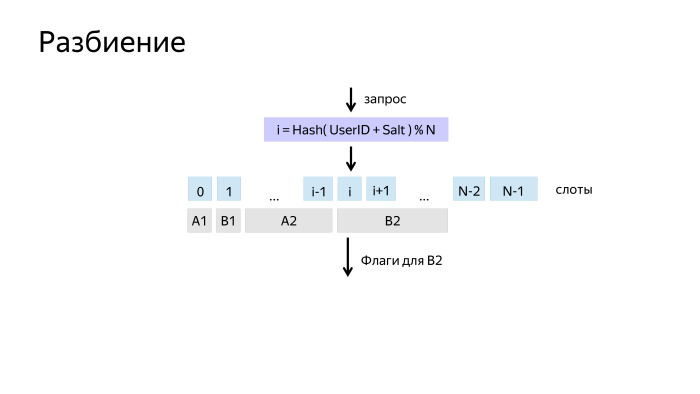

Простое решение — взять хэш от идентификатора пользователя и взять по модулю N. Получаем N возможных исходов и называем их слотами. Такое разбиение обычно называют измерением.

Потом на слоты можно навесить эксперименты и алгоритмы. Но здесь возникает проблема. Допустим, перед нами работал эксперимент, в котором пользователям в одной выборке было хорошо, а в другой — чуть хуже. После отключения эксперимента пользователи привыкли и начали вести себя по-разному. И когда включается новый эксперимент на тех же слотах, возникает смещение — A и B находятся в неравных условиях.

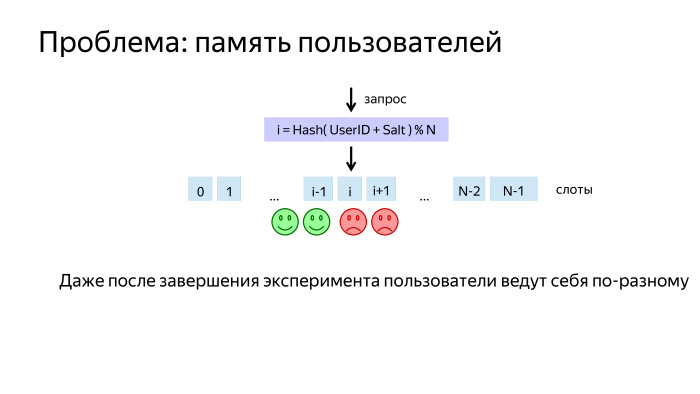

Благодаря тому, что алгоритм разбиения — граф, можно сделать так: перемешать пользователей ещё раз перед тем, как они вновь попадут в выборку A и B. Тем самым обеспечиваются равные условия.

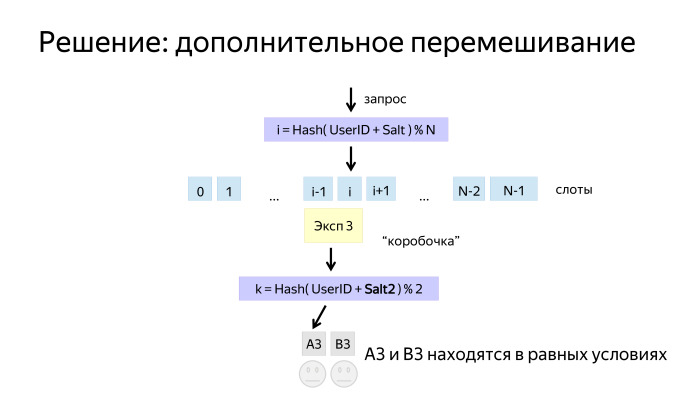

Многомерная схема тоже выглядит довольно просто: есть специальная нода, которая распараллеливает обход графа. Обход происходит независимо на каждой ветке, и потом результат складывается.

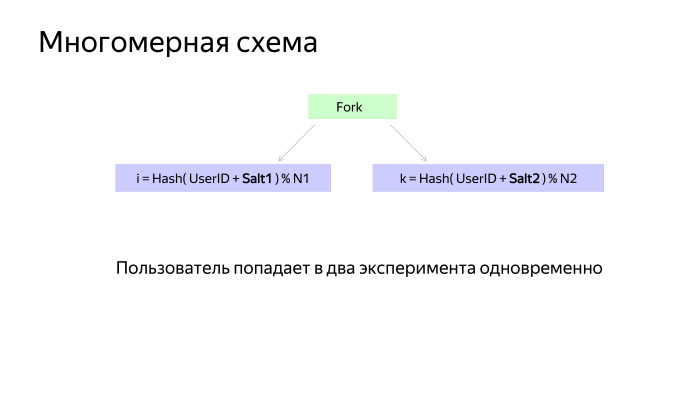

Когда измерения ведутся в разных ветках, они обычно имеют Salt1 и Salt2 — соль, чтобы они бились независимо и не коррелировали друг с другом.

In [66]:
# 23.1
def assign_group(user_id, salt, n_buckets=100):
    b = bucket(user_id, salt, n_buckets)   # bucket() определена в разделе 17
    return "test" if b < n_buckets // 2 else "control"

user_ids = [f"user_{i}" for i in range(5000)]

# ту же соль используем повторно для второго "измерения" -- имитация отсутствия соления
group_layer1 = np.array([assign_group(uid, "layer1") for uid in user_ids])
group_layer1_again = np.array([assign_group(uid, "layer1") for uid in user_ids])   # та же соль
match_same_salt = (group_layer1 == group_layer1_again).mean()

# разные соли (Salt1 vs Salt2) для двух независимых измерений
group_salt1 = np.array([assign_group(uid, "Salt1") for uid in user_ids])
group_salt2 = np.array([assign_group(uid, "Salt2") for uid in user_ids])
match_diff_salt = (group_salt1 == group_salt2).mean()

print(f"Совпадение групп между двумя измерениями при ОДНОЙ и той же соли: {match_same_salt:.0%}")
print("  -> назначения полностью коррелируют: кто был в test, снова в test (именно та проблема смещения, что описана выше)")
print(f"\nСовпадение групп между измерениями при РАЗНОЙ соли (Salt1 vs Salt2): {match_diff_salt:.0%}")
print("  -> около 50%, то есть назначения независимы, как и требуется")

Совпадение групп между двумя измерениями при ОДНОЙ и той же соли: 100%
  -> назначения полностью коррелируют: кто был в test, снова в test (именно та проблема смещения, что описана выше)

Совпадение групп между измерениями при РАЗНОЙ соли (Salt1 vs Salt2): 50%
  -> около 50%, то есть назначения независимы, как и требуется


## 24. Sequential testing (проблема подглядывания)

Всё, что было в конспекте про размер выборки и α/β (раздел 16), предполагает **fixed-horizon дизайн**: размер выборки посчитан заранее, тест идёт ровно нужное время, результат смотрят один раз в конце. Это же предположение неявно используется во всех p-value, которые встречались выше — формулы t-теста и z-теста выводятся именно для одного-единственного взгляда на данные.

**Проблема подглядывания (peeking problem).** На практике почти никто не ждёт молча: p-value проверяют каждый день, и как только он падает ниже 0.05 — тест останавливают и объявляют победу. Каждая такая проверка — это ещё один шанс, что p-value случайно нырнёт ниже 0.05 просто от шума, даже если реального эффекта нет вообще. Это тот же принцип, что множественное тестирование (раздел 29), только не по разным метрикам, а по разным моментам времени одной и той же метрики.

**Решения**
- **Group sequential design с alpha-spending функциями** — заранее фиксируют количество и моменты «взглядов» и распределяют общий бюджет ошибки I рода между ними по определённой функции. O'Brien-Fleming тратит очень мало альфы на ранних взглядах (почти невозможно остановиться рано) и почти всю — на последнем; Pocock использует одинаково строгий порог на каждом взгляде.
- **Always-valid p-values / mSPRT** (mixture Sequential Probability Ratio Test) — более новый подход из индустрии, специально сконструированный так, чтобы p-value оставалось корректным при остановке в ЛЮБОЙ момент, а не только в заранее оговорренный. Позволяет по-настоящему непрерывный мониторинг без инфляции ошибки I рода.

Это один из самых частых вопросов-ловушек на собеседованиях: «а что если продакт хочет посмотреть на результат через 3 дня вместо запланированных двух недель?».

**Насколько сильно раздувается ошибка I рода при обычном подглядывании.** H₀ верна (эффекта нет), но каждый день добавляется порция данных и p-value проверяется заново — тест останавливают при первом p < 0.05.

In [67]:
# 24.1
np.random.seed(90)
n_sims = 2000
n_looks = 10
n_per_look = 50   # порция новых пользователей на группу при каждом "взгляде"

def run_peeking_experiment(alpha_threshold, true_effect=0.0):
    a_cum, b_cum = np.array([]), np.array([])
    for _ in range(n_looks):
        a_cum = np.r_[a_cum, np.random.normal(0, 1, n_per_look)]
        b_cum = np.r_[b_cum, np.random.normal(true_effect, 1, n_per_look)]
        _, p = stats.ttest_ind(a_cum, b_cum)
        if p < alpha_threshold:
            return True
    return False

fpr_peeking = np.mean([run_peeking_experiment(0.05) for _ in range(n_sims)])
print(f"H0 верна, {n_looks} взглядов, порог 0.05 на каждом взгляде:")
print(f"Наблюдаемая ошибка I рода = {fpr_peeking:.1%}  (вместо заявленных 5%)")

H0 верна, 10 взглядов, порог 0.05 на каждом взгляде:
Наблюдаемая ошибка I рода = 19.7%  (вместо заявленных 5%)


**Простая калибровка через симуляцию** — аналог идеи alpha-spending: если заранее знаем число взглядов, можно подобрать более строгий порог для каждого взгляда так, чтобы итоговая ошибка I рода вернулась к 5%.

In [68]:
# 24.2
for alpha_try in [0.05, 0.02, 0.012, 0.01, 0.008]:
    fpr = np.mean([run_peeking_experiment(alpha_try) for _ in range(1200)])
    print(f"порог на каждом взгляде = {alpha_try:<5}: итоговая ошибка I рода за {n_looks} взглядов = {fpr:.1%}")

print("\nПорог около 0.01 на каждый из 10 взглядов возвращает итоговую ошибку I рода обратно к ~5%.")
print("Это упрощённая иллюстрация идеи alpha-spending -- в проде вместо ручной калибровки используют")
print("готовые функции (O'Brien-Fleming, Pocock) или always-valid p-values (mSPRT).")

порог на каждом взгляде = 0.05 : итоговая ошибка I рода за 10 взглядов = 20.2%


порог на каждом взгляде = 0.02 : итоговая ошибка I рода за 10 взглядов = 8.6%


порог на каждом взгляде = 0.012: итоговая ошибка I рода за 10 взглядов = 5.8%


порог на каждом взгляде = 0.01 : итоговая ошибка I рода за 10 взглядов = 4.9%


порог на каждом взгляде = 0.008: итоговая ошибка I рода за 10 взглядов = 4.8%

Порог около 0.01 на каждый из 10 взглядов возвращает итоговую ошибку I рода обратно к ~5%.
Это упрощённая иллюстрация идеи alpha-spending -- в проде вместо ручной калибровки используют
готовые функции (O'Brien-Fleming, Pocock) или always-valid p-values (mSPRT).


## 25. Байесовский подход к A/B-тестированию

Всё, что было в конспекте до сих пор, — частотный (frequentist) подход: p-value отвечает на вопрос «насколько вероятно получить такие (или ещё более крайние) данные, если верна H₀?». Байесовский подход задаёт вопрос иначе и прямо: «какова вероятность, что вариант B лучше A, учитывая то, что мы уже видели?»

**Модель для конверсии: Beta-Binomial.** Конверсия — параметр биномиального распределения (раздел 3). Если взять для него prior-распределение Beta(a, b), после наблюдения данных апостериорное распределение тоже оказывается Beta — в закрытом виде, без сложных вычислений:

$$p \sim \text{Beta}(a, b) \quad\Rightarrow\quad p\,|\,\text{данные} \sim \text{Beta}(a + \text{успехи},\ b + \text{неудачи})$$

Beta(1, 1) — равномерное распределение на [0, 1], то есть «неинформативный» prior: до данных считаем все значения конверсии равновероятными.

**Итоговые величины**
- **P(B > A | данные)** — вероятность, что B действительно лучше A, считается через Monte Carlo: генерируем много пар сэмплов из апостериорных распределений A и B и смотрим долю случаев, где B > A.
- **Expected loss** — ожидаемая цена ошибки, если выбрать не тот вариант. Даёт прямой бизнес-ответ вместо бинарного «значимо / не значимо».

**Frequentist vs Bayesian**

| | Frequentist | Bayesian |
|---|---|---|
| Что отвечает | P(данные такие или более крайние \| H₀ верна) | P(гипотеза верна \| данные) |
| Интерпретация | Через гипотетические повторения эксперимента, менее интуитивна | Прямое вероятностное утверждение о параметре, интуитивнее для бизнеса |
| Предварительные предположения | Не нужен prior | Нужно задать prior (при неинформативном — минимальное влияние) |
| Многократные проверки | Требует явной коррекции (раздел 24) | Не даёт автоматической защиты «из коробки» тоже — наивное байесовское подглядывание так же искажает вывод, нужны свои поправки |
| Итоговое решение | p-value / доверительный интервал | Вероятность + expected loss — более прямая связка с бизнес-решением |

Возьмём данные из раздела 3 (control: 410/5000, test: 460/5000 — там z-тест дал пограничный результат, p≈0.076) и посмотрим на них байесовски.

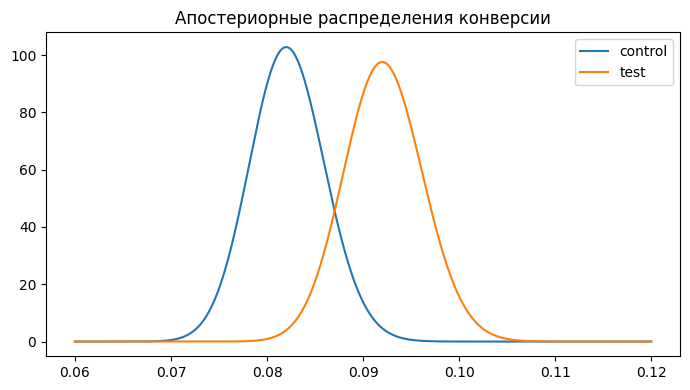

In [69]:
# 25.1
alpha_prior, beta_prior = 1, 1   # Beta(1,1) - неинформативный prior

post_control = stats.beta(alpha_prior + conv_control, beta_prior + n_control - conv_control)
post_test = stats.beta(alpha_prior + conv_test, beta_prior + n_test - conv_test)

x = np.linspace(0.06, 0.12, 500)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, post_control.pdf(x), label="control")
ax.plot(x, post_test.pdf(x), label="test")
ax.legend()
ax.set_title("Апостериорные распределения конверсии")
plt.tight_layout()
plt.show()

In [70]:
# 25.2
np.random.seed(95)
n_mc = 200_000
samples_control = post_control.rvs(n_mc)
samples_test = post_test.rvs(n_mc)

prob_test_better = np.mean(samples_test > samples_control)
loss_if_choose_test = np.mean(np.maximum(samples_control - samples_test, 0))
loss_if_choose_control = np.mean(np.maximum(samples_test - samples_control, 0))

print(f"P(конверсия test > control | данные) = {prob_test_better:.1%}")
print(f"\nExpected loss, если выберем test:    {loss_if_choose_test:.5f}")
print(f"Expected loss, если выберем control: {loss_if_choose_control:.5f}")
print(f"\nХотя z-тест из раздела 3 дал пограничный p≈0.076 ('не значимо' по обычному порогу 0.05),")
print(f"байесовская оценка прямо говорит: вероятность, что test лучше — {prob_test_better:.0%}, а цена ошибки")
print(f"при выборе control в {loss_if_choose_control/loss_if_choose_test:.0f} раз выше, чем при выборе test.")

P(конверсия test > control | данные) = 96.2%

Expected loss, если выберем test:    0.00009
Expected loss, если выберем control: 0.01010

Хотя z-тест из раздела 3 дал пограничный p≈0.076 ('не значимо' по обычному порогу 0.05),
байесовская оценка прямо говорит: вероятность, что test лучше — 96%, а цена ошибки
при выборе control в 117 раз выше, чем при выборе test.


## 26. Интерференция и network effects

Все тесты в этом конспекте молчаливо опираются на SUTVA (Stable Unit Treatment Value Assumption) — предположение, что исход одного пользователя зависит только от ЕГО СОБСТВЕННОГО варианта теста, а не от того, в какой группе оказались другие пользователи.

**Когда это ломается**: маркетплейсы и шеринговые платформы (продавцы/водители/курьеры — общий ограниченный ресурс на test и control одновременно), социальные функции (действие одного пользователя видят его друзья, которые могут быть в другой группе), любой общий лимитированный ресурс (рекламный инвентарь, бюджет пушей, ограниченная пропускная способность).

**Последствия.** Если ресурс общий и ограниченный, а test-пользователи начинают «отъедать» его у control (или наоборот), наивное индивидуальное А/Б сравнение измеряет не реальный эффект, а частично (или полностью) — перераспределение фиксированного пирога между группами. Результат может быть как завышен, так и занижен в зависимости от направления эффекта.

**Способы борьбы**
- **Кластерная / гео-рандомизация** — рандомизируют не отдельных пользователей, а целые кластеры (город, рынок, социальное сообщество), чтобы большинство взаимодействий происходило внутри кластера, и test/control не делили один и тот же ограниченный ресурс.
- **Switchback-эксперименты** — рандомизация по времени: вся система целиком находится в состоянии test какое-то время, потом целиком в состоянии control. Часто применяется именно для маркетплейсов, где сложно разделить людей физически.
- **Рандомизация по эго-сетям** — для социальных связей: пользователь и его ближайшее окружение помещаются в один и тот же вариант теста, чтобы минимизировать «утечку» эффекта между группами.

**Иллюстрация: маркетплейс с фиксированным предложением** (например, число доступных водителей в городе). Тестируем алгоритм, который даёт test-пользователям приоритет в подборе. Сравним индивидуальную рандомизацию (test и control в одном городе делят один и тот же ограниченный пул водителей) с кластерной (город целиком test или целиком control).

In [71]:
# 26.1
np.random.seed(101)
n_cities = 60
drivers_per_city = 30     # фиксированное предложение на город
riders_per_city = 50      # спрос выше предложения -- дефицит

def simulate_market(pct_treated, boost, individual_random=True):
    test_rates, control_rates = [], []
    for _ in range(n_cities):
        if individual_random:
            is_test = np.random.rand(riders_per_city) < pct_treated
        else:
            city_is_test = np.random.rand() < pct_treated
            is_test = np.full(riders_per_city, city_is_test)
        # приоритет: у test-пользователя эффективный "счёт в очереди" ниже (значит, выше приоритет)
        priority_score = np.random.rand(riders_per_city) - is_test * boost
        matched_idx = np.argsort(priority_score)[:drivers_per_city]
        matched = np.zeros(riders_per_city, dtype=bool)
        matched[matched_idx] = True
        if is_test.sum() > 0:
            test_rates.append(matched[is_test].mean())
        if (~is_test).sum() > 0:
            control_rates.append(matched[~is_test].mean())
    return np.mean(test_rates), np.mean(control_rates)

t_mixed, c_mixed = simulate_market(pct_treated=0.5, boost=0.3, individual_random=True)
t_cluster, c_cluster = simulate_market(pct_treated=0.5, boost=0.3, individual_random=False)

print("Индивидуальная рандомизация (test и control делят один пул водителей в городе):")
print(f"  match rate test = {t_mixed:.1%}, control = {c_mixed:.1%}, разница = {t_mixed - c_mixed:+.1%}")
print("\nКластерная рандомизация (город целиком test ИЛИ целиком control):")
print(f"  match rate test = {t_cluster:.1%}, control = {c_cluster:.1%}, разница = {t_cluster - c_cluster:+.1%}")
print("\nПри индивидуальной рандомизации кажется, что эффект огромный (+32 п.п.) -- но это чистое перераспределение")
print("одного и того же ограниченного числа водителей от control к test. Кластерная рандомизация показывает правду:")
print("реального прироста нет вообще, потому что суммарное предложение в городе не меняется ни при каком алгоритме.")

Индивидуальная рандомизация (test и control делят один пул водителей в городе):
  match rate test = 76.0%, control = 43.5%, разница = +32.5%

Кластерная рандомизация (город целиком test ИЛИ целиком control):
  match rate test = 60.0%, control = 60.0%, разница = +0.0%

При индивидуальной рандомизации кажется, что эффект огромный (+32 п.п.) -- но это чистое перераспределение
одного и того же ограниченного числа водителей от control к test. Кластерная рандомизация показывает правду:
реального прироста нет вообще, потому что суммарное предложение в городе не меняется ни при каком алгоритме.


## 27. Многорукие бандиты

Альтернатива фиксированному сплиту A/B-теста: вместо того, чтобы весь тест держать равные доли трафика на каждый вариант, доли **адаптивно** сдвигаются в сторону варианта, который по ходу теста выглядит лучше.

**Цель — минимизировать regret** (накопленные потери от показа пользователям худшего варианта) прямо во время теста, а не только сделать вывод постфактум.

**Thompson Sampling** — байесовский алгоритм (прямое продолжение раздела 25): для каждого варианта («руки» бандита) поддерживается апостериорное распределение его истинной конверсии. На каждом раунде из апостериорного распределения КАЖДОГО варианта берётся один случайный сэмпл, и показывается пользователю тот вариант, у которого сэмпл оказался наибольшим. Это естественно балансирует exploration (у неопределённых вариантов разброс сэмплов больше — у них есть шанс "выиграть" случайно и получить дополнительные данные) и exploitation (уверенно хороший вариант обычно и выигрывает).

Другие классические алгоритмы: **epsilon-greedy** (в основном показывать текущего лидера, изредка — случайный вариант) и **UCB / Upper Confidence Bound** (выбирать вариант с наибольшей верхней границей доверительного интервала оценки).

**Компромисс с классическим A/B-тестом.** Традиционный тест оптимизирует **обучение** (статистическую мощность, чистую оценку размера эффекта с валидным доверительным интервалом) — ради этого он жертвует частью трафика на заведомо (по итогу) худший вариант. Бандит оптимизирует **заработок прямо во время теста** (минимизирует regret) — но ценой того, что итоговые данные собраны не поровну, и классические формулы p-value/CI для них уже не совсем корректны без специальных поправок. Нельзя одновременно максимально быстро *учиться* и максимально быстро *зарабатывать* — это разные цели, и выбор между ними зависит от того, что важнее в конкретной ситуации.

Три варианта кнопки с разной истинной конверсией. Сравним накопленный regret Thompson Sampling против традиционного равного сплита на одинаковом числе показов.

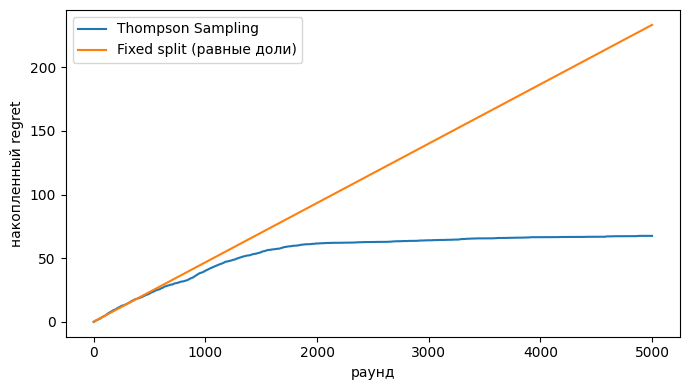

Итоговый накопленный regret: Thompson Sampling = 67.6, Fixed split = 233.4
Thompson Sampling накопил в 3.5 раз меньше потерь за счёт того, что быстро
сместил основную часть трафика на лучший вариант, вместо того чтобы держать равные доли до самого конца.


In [72]:
# 27.1
np.random.seed(110)
true_rates = [0.10, 0.12, 0.18]
n_rounds = 5000

def thompson_sampling(true_rates, n_rounds):
    n_arms = len(true_rates)
    successes, failures = np.ones(n_arms), np.ones(n_arms)   # Beta(1,1) prior на каждую руку
    regret = np.zeros(n_rounds)
    best_rate = max(true_rates)
    for t in range(n_rounds):
        samples = np.random.beta(successes, failures)
        arm = np.argmax(samples)
        reward = np.random.rand() < true_rates[arm]
        successes[arm] += reward
        failures[arm] += (1 - reward)
        regret[t] = best_rate - true_rates[arm]
    return np.cumsum(regret)

def fixed_split(true_rates, n_rounds):
    n_arms = len(true_rates)
    regret = np.zeros(n_rounds)
    best_rate = max(true_rates)
    for t in range(n_rounds):
        arm = t % n_arms
        regret[t] = best_rate - true_rates[arm]
    return np.cumsum(regret)

cum_regret_ts = thompson_sampling(true_rates, n_rounds)
cum_regret_fixed = fixed_split(true_rates, n_rounds)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cum_regret_ts, label="Thompson Sampling")
ax.plot(cum_regret_fixed, label="Fixed split (равные доли)")
ax.legend()
ax.set_xlabel("раунд")
ax.set_ylabel("накопленный regret")
plt.tight_layout()
plt.show()

print(f"Итоговый накопленный regret: Thompson Sampling = {cum_regret_ts[-1]:.1f}, Fixed split = {cum_regret_fixed[-1]:.1f}")
print(f"Thompson Sampling накопил в {cum_regret_fixed[-1]/cum_regret_ts[-1]:.1f} раз меньше потерь за счёт того, что быстро")
print("сместил основную часть трафика на лучший вариант, вместо того чтобы держать равные доли до самого конца.")

## 28. A/A-тесты

A/A-тест — это тот же самый пайплайн эксперимента (рандомизация, бакетирование, логирование, расчёт метрик), что и в реальном A/B-тесте, но обеим группам показывается АБСОЛЮТНО одинаковый опыт. Реального эффекта там нет и быть не может по построению.

**Зачем это нужно.** Это не проверка гипотезы о продукте — это health-check самого измерительного пайплайна. Если всё работает правильно, то при многократном повторении A/A-теста p-value должно распределяться **равномерно** на [0, 1] (потому что H₀ всегда истинна по построению) — то есть примерно 5% тестов будут случайно показывать p < 0.05, и это нормально, а не ошибка. Ненормально — если доля значимых результатов систематически намного выше 5% или распределение p-value явно перекошено: это обычно означает, что где-то в пайплайне баг (некорректная рандомизация, задвоение пользователей, отличающийся способ подсчёта метрики между группами и т.д.), причём совершенно независимо от того, что происходит в конкретном A/B-тесте поверх этого пайплайна.

**Смежная проверка — Sample Ratio Mismatch (SRM).** Отдельно стоит сверять фактический размер групп с ожидаемым (обычно 50/50) через хи-квадрат тест на согласие. Значимый SRM — один из самых частых и самых тревожных сигналов на практике: почти всегда означает баг в рандомизации или разную потерю данных между группами, а не «повезло-не повезло».

**Здоровый пайплайн.** Много раз запускаем A/A-тест (обе группы — из одного и того же процесса). Распределение p-value должно быть близко к равномерному.

Доля p<0.05: 4.3%  (ожидаем ~5%)
KS-тест на равномерность p-value: statistic=0.0174, p=0.7491  (высокий p -> не отвергаем равномерность, всё в порядке)


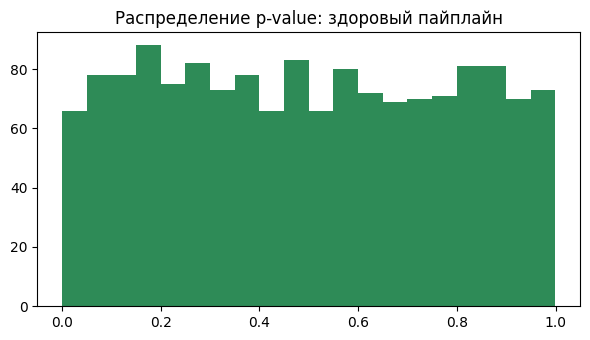

In [73]:
# 28.1
np.random.seed(120)
n_aa_tests = 1500
n_per_group = 200

pvals_healthy = []
for _ in range(n_aa_tests):
    a = np.random.normal(100, 20, n_per_group)
    b = np.random.normal(100, 20, n_per_group)   # тот же самый процесс, никакого различия
    _, p = stats.ttest_ind(a, b)
    pvals_healthy.append(p)
pvals_healthy = np.array(pvals_healthy)

ks_stat, ks_p = stats.kstest(pvals_healthy, "uniform")
print(f"Доля p<0.05: {(pvals_healthy < 0.05).mean():.1%}  (ожидаем ~5%)")
print(f"KS-тест на равномерность p-value: statistic={ks_stat:.4f}, p={ks_p:.4f}  (высокий p -> не отвергаем равномерность, всё в порядке)")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(pvals_healthy, bins=20, color="seagreen")
ax.set_title("Распределение p-value: здоровый пайплайн")
plt.tight_layout()
plt.show()

**Сломанный пайплайн.** Классический реальный баг: рандомизация проведена на уровне ПОЛЬЗОВАТЕЛЕЙ, а анализ по ошибке считает независимыми наблюдениями отдельные СЕССИИ одного и того же пользователя (несколько сильно скоррелированных наблюдений на одного человека, но t-test думает, что это независимые точки данных).

Доля p<0.05: 39.0%  (должно быть ~5%, а не так)
KS-тест на равномерность p-value: statistic=0.3875, p=2.84e-203  (крайне низкий p -> явно не равномерно)


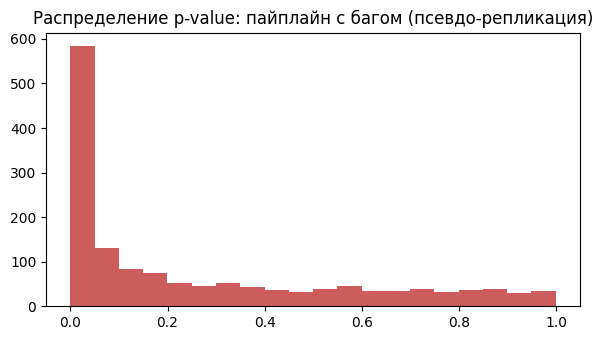


Рандомизация была честной на уровне пользователя, но анализ на уровне сессий занизил стандартную ошибку
(меньше реально независимой информации, чем кажется по числу строк) -- и ошибка I рода взлетела с 5% почти до 40%.


In [74]:
# 28.2
np.random.seed(121)
n_users_pool = 80
sessions_per_user = 5

pvals_broken = []
for _ in range(n_aa_tests):
    user_baseline = np.random.normal(100, 20, n_users_pool)
    user_group = np.random.randint(0, 2, n_users_pool)   # рандомизация ЧЕСТНАЯ, на уровне пользователя
    a_sessions, b_sessions = [], []
    for u in range(n_users_pool):
        sessions = user_baseline[u] + np.random.normal(0, 5, sessions_per_user)   # сессии одного юзера сильно коррелируют
        (a_sessions if user_group[u] == 0 else b_sessions).extend(sessions)
    _, p = stats.ttest_ind(a_sessions, b_sessions)   # ОШИБКА АНАЛИЗА: сессии считаются независимыми наблюдениями
    pvals_broken.append(p)
pvals_broken = np.array(pvals_broken)

ks_stat2, ks_p2 = stats.kstest(pvals_broken, "uniform")
print(f"Доля p<0.05: {(pvals_broken < 0.05).mean():.1%}  (должно быть ~5%, а не так)")
print(f"KS-тест на равномерность p-value: statistic={ks_stat2:.4f}, p={ks_p2:.2e}  (крайне низкий p -> явно не равномерно)")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(pvals_broken, bins=20, color="indianred")
ax.set_title("Распределение p-value: пайплайн с багом (псевдо-репликация)")
plt.tight_layout()
plt.show()
print("\nРандомизация была честной на уровне пользователя, но анализ на уровне сессий занизил стандартную ошибку")
print("(меньше реально независимой информации, чем кажется по числу строк) -- и ошибка I рода взлетела с 5% почти до 40%.")

**Sample Ratio Mismatch (SRM).** Отдельная, более простая проверка: соответствует ли фактический размер групп ожидаемому.

In [75]:
# 28.3
n_a, n_b = 5120, 4880   # ожидали ровно 50/50
chi2_srm, p_srm = stats.chisquare([n_a, n_b], f_exp=[(n_a + n_b) / 2, (n_a + n_b) / 2])
print(f"n_A = {n_a}, n_B = {n_b} (перекос всего {abs(n_a-n_b)/(n_a+n_b):.1%})")
print(f"SRM chi2 = {chi2_srm:.2f}, p = {p_srm:.4f}")
print(f"-> {'SRM: перекос статистически значим, дальше анализировать результаты теста небезопасно' if p_srm < 0.05 else 'перекос в пределах случайного шума'}")

n_A = 5120, n_B = 4880 (перекос всего 2.4%)
SRM chi2 = 5.76, p = 0.0164
-> SRM: перекос статистически значим, дальше анализировать результаты теста небезопасно


## 29. Ошибки в А/Б тестах

Мы провели А/Б-тест, раскатали тестовую группу, потому что она победила, но целевой показатель упал. Что могло пойти не так? Открытый вопрос, который отлично показывает, как плотно человек работал с А/Б-тестами.

**Ошибки в дизайне теста**
- *Неправильная выборка*: группы могли быть несбалансированы по ключевым характеристикам (возраст, регион, поведение) — стоит проверить, использовались ли стратификация (раздел 21) или рандомизация, и не было ли SRM (раздел 28).
- *Недостаточный размер выборки*: результат мог быть статистически незначим — стоит пересчитать минимально необходимый размер выборки через power analysis (раздел 16).
- *Короткий период теста*: сезонные факторы или временные эффекты могли исказить результат — стоит проверить длительность теста и стабильность метрик.

**Проблемы с метриками**
- *Неправильный выбор целевой метрики*: например, CTR мог не отражать долгосрочный эффект (например, удержание) — стоит проверить корреляцию тестовой метрики с бизнес-целями.
- *Новизна эффекта*: пользователи могли активно реагировать на нововведение в тесте, но эффект угас после раскатки — стоит анализировать долгосрочные метрики (LTV, retention).
- *Каннибализация других метрик*: улучшение одной метрики (например, конверсии) могло ухудшить другую (например, средний чек).

**Внешние факторы**
- *Сезонность или внешние события*: после раскатки могли измениться внешние условия (праздники, конкуренты, экономическая ситуация).
- *Изменение аудитории*: если раскатка затронула более широкую аудиторию, чем тестовая выборка, эффект мог не масштабироваться. Сюда же — интерференция и network effects (раздел 26): в тесте участвовал лишь кусочек общего ограниченного ресурса, а после раскатки на 100% пирог делить стало не с кем.

**Технические ошибки**
- *Проблемы с реализацией*: раскатка могла быть выполнена некорректно (баги в коде, неверные настройки).
- *Логирование данных*: ошибки в сборе данных (например, пропущенные события) могли исказить результаты теста.

**Статистические ошибки**
- *Ложноположительный результат*: если уровень значимости был слишком мягким (например, α = 0.1 вместо 0.05), тест мог показать значимость случайно.
- *Множественное тестирование*: если тестировалось много гипотез без поправки (раздел 11 — Bonferroni/Holm/BH), результат мог быть случайным.
- *Пост-хок разрезы по сегментам*: если общий эффект теста был незначим, но кто-то «поресёрчил» и нашёл значимый эффект в одном из сегментов (например, «зато у iOS сработало!») уже после того, как увидели данные — это по сути то же самое множественное тестирование, просто незапланированное и без коррекции. Такой найденный «эффект» нужно перепроверять на новых данных, а не сразу принимать решение.
- *Подглядывание (peeking)*: тест мог быть остановлен раньше срока по первому благоприятному p-value (раздел 24) — тогда заявленный p-value недостоверен.
- *Ненормальное распределение p-value в А/А тесте* (раздел 28) — верный признак, что что-то в системе сплитования или сборе данных сломано ещё до всякого А/Б.

**Множественное тестирование без поправки — насколько это опасно на практике.** Просимулируем ситуацию, где реального эффекта нет ни в одной из 20 метрик, но мы проверяем их все на уровне α = 0.05 без коррекции.

In [76]:
# 29.1
np.random.seed(37)
n_metrics = 20
n_sims = 3000
alpha = 0.05

at_least_one_false_positive = 0
for _ in range(n_sims):
    pvals = np.array([stats.ttest_ind(np.random.normal(0, 1, 200), np.random.normal(0, 1, 200)).pvalue
                       for _ in range(n_metrics)])
    if (pvals < alpha).any():
        at_least_one_false_positive += 1

print(f"Метрик проверяем за раз: {n_metrics}, реального эффекта нет ни в одной")
print(f"Доля симуляций, где хотя бы одна метрика 'случайно' оказалась значимой: {at_least_one_false_positive/n_sims:.1%}")
print(f"(по формуле: 1 - (1-{alpha})^{n_metrics} = {1 - (1-alpha)**n_metrics:.1%})")
print("\nПри 20 непроверяемых метриках вероятность хотя бы одного ложного срабатывания приближается к 65%, а не к заявленным 5%.")
print("Поправка Бонферрони в этом случае: использовать альфа =", round(alpha / n_metrics, 4), "для каждой отдельной метрики.")

Метрик проверяем за раз: 20, реального эффекта нет ни в одной
Доля симуляций, где хотя бы одна метрика 'случайно' оказалась значимой: 62.8%
(по формуле: 1 - (1-0.05)^20 = 64.2%)

При 20 непроверяемых метриках вероятность хотя бы одного ложного срабатывания приближается к 65%, а не к заявленным 5%.
Поправка Бонферрони в этом случае: использовать альфа = 0.0025 для каждой отдельной метрики.


## 30. Разные разности

### Парадокс Симпсона

Статистический феномен, при котором тенденция или взаимосвязь, наблюдаемая в нескольких группах данных, полностью исчезает или меняется на противоположную, когда эти группы объединяются.

Возникает из-за наличия скрытых факторов (сопутствующих переменных), которые неравномерно распределены между группами и искажают общую картину (классический пример — кажущийся половой перекос при поступлении в институт, объясняющийся на самом деле выбором факультета).

In [77]:
# 30.1
depts = pd.DataFrame({
    "факультет": ["A (лёгкий)", "A (лёгкий)", "B (сложный)", "B (сложный)"],
    "пол": ["мужчины", "женщины", "мужчины", "женщины"],
    "подали": [800, 100, 100, 800],
    "приняли": [600, 82, 15, 152],
})
depts["доля принятых"] = (depts["приняли"] / depts["подали"]).round(3)
print(depts.to_string(index=False))
print("\nНа факультете A доля принятых женщин выше (82% против 75%), на факультете B — тоже выше (19% против 15%).")

overall = depts.groupby("пол")[["подали", "приняли"]].sum()
overall["доля принятых"] = (overall["приняли"] / overall["подали"]).round(3)
print("\nНо если сложить оба факультета вместе:")
print(overall)
print("\n-> у мужчин общая доля принятых выше, хотя на каждом факультете по отдельности верно обратное.")
print("Скрытая переменная: женщины гораздо чаще подают документы именно на сложный факультет B, где ниже проходимость вообще у всех.")

  факультет     пол  подали  приняли  доля принятых
 A (лёгкий) мужчины     800      600           0.75
 A (лёгкий) женщины     100       82           0.82
B (сложный) мужчины     100       15           0.15
B (сложный) женщины     800      152           0.19

На факультете A доля принятых женщин выше (82% против 75%), на факультете B — тоже выше (19% против 15%).

Но если сложить оба факультета вместе:
         подали  приняли  доля принятых
пол                                    
женщины     900      234          0.260
мужчины     900      615          0.683

-> у мужчин общая доля принятых выше, хотя на каждом факультете по отдельности верно обратное.
Скрытая переменная: женщины гораздо чаще подают документы именно на сложный факультет B, где ниже проходимость вообще у всех.


### Кластеризация

```
1. Постановка задачи → 2. Выбор объектов → 3. Выбор признаков → 4. Предобработка данных
→ 5. Выбор алгоритма → 6. Подбор числа кластеров → 7. Обучение модели
→ 8. Оценка качества → 9. Интерпретация кластеров → 10. Валидация и использование
```

1. **Постановка задачи** — зачем вообще нужна кластеризация: сегментация пользователей, поиск аномалий (как первый этап), персонализация рекомендаций, поиск похожих товаров.
2. **Выбор объектов** — что кластеризуем: пользователей, товары, магазины, города.
3. **Выбор признаков** — именно признаки в основном определяют качество кластеризации. Например, для пользователей: возраст, ARPU, число заказов, средний чек, частота посещений.
4. **Предобработка** — обработка пропусков, удаление выбросов (при необходимости), кодирование категориальных признаков, масштабирование (очень важно для методов на основе расстояний, например k-means).
5. **Выбор алгоритма** (зависит от данных и задачи) — самые популярные: K-Means, Hierarchical Clustering, DBSCAN, Gaussian Mixture Models.
6. **Выбор числа кластеров** — для K-Means обычно Elbow Method, Silhouette Score, иногда Gap Statistic.
7. **Обучение** — запускаем алгоритм и получаем номер кластера для каждого объекта.
8. **Оценка качества** — Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index.
9. **Интерпретация** — самый важный этап для аналитика, здесь уже начинается бизнес-анализ (например: кластер 1 — новые пользователи, кластер 2 — постоянные покупатели, кластер 3 — VIP-клиенты, кластер 4 — пользователи с риском оттока).
10. **Использование** — разные акции, разные рекомендации, разные модели прогнозирования, разные стратегии удержания.

Что обычно ждут на собеседовании: поставить задачу → выбрать признаки → подготовить данные (в том числе масштабировать) → выбрать алгоритм → подобрать число кластеров → оценить качество → интерпретировать кластеры.

In [78]:
# 30.2
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 2-3. Объекты - пользователи; признаки - возраст, ARPU, число заказов, частота визитов
np.random.seed(41)

def gen_segment(n, age_mean, arpu_mean, orders_mean, freq_mean):
    return pd.DataFrame({
        "age": np.random.normal(age_mean, 4, n).clip(16, 70),
        "arpu": np.random.gamma(4, arpu_mean / 4, n),
        "orders": np.random.poisson(orders_mean, n),
        "visit_freq": np.random.gamma(3, freq_mean / 3, n),
    })

users = pd.concat([
    gen_segment(300, 22, 15, 1, 2),     # похоже на новых пользователей
    gen_segment(400, 35, 60, 8, 10),    # похоже на постоянных покупателей
    gen_segment(100, 40, 220, 25, 20),  # похоже на VIP
    gen_segment(200, 45, 20, 1, 1),     # похоже на риск оттока
], ignore_index=True)

# 4. Предобработка - масштабирование (пропусков и выбросов в синтетике нет)
features = ["age", "arpu", "orders", "visit_freq"]
X_scaled = StandardScaler().fit_transform(users[features])

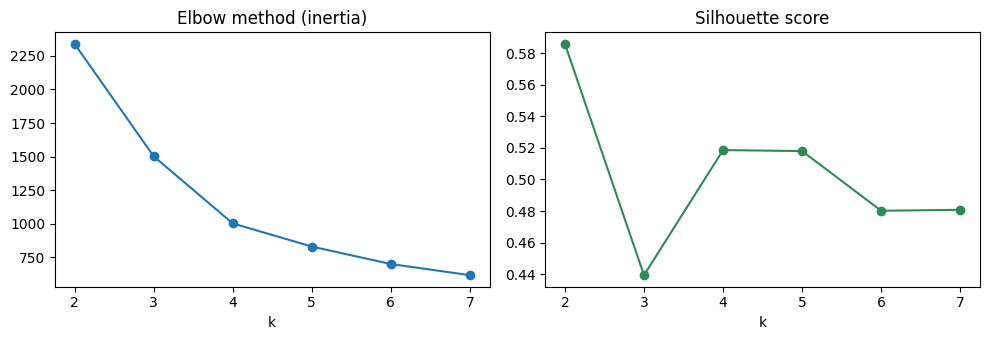

Лучшее k по silhouette score: 2


In [79]:
# 30.3
# 6. Подбор числа кластеров: Elbow + Silhouette
k_range = range(2, 8)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow method (inertia)")
axes[0].set_xlabel("k")
axes[1].plot(list(k_range), silhouettes, marker="o", color="seagreen")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"Лучшее k по silhouette score: {best_k}")

In [80]:
# 30.4
# 7. Обучение финальной модели
kmeans_final = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit(X_scaled)
users["cluster"] = kmeans_final.labels_

# 8. Оценка качества
sil = silhouette_score(X_scaled, users["cluster"])
db = davies_bouldin_score(X_scaled, users["cluster"])
print(f"Silhouette score: {sil:.3f}  (чем ближе к 1, тем лучше)")
print(f"Davies-Bouldin index: {db:.3f}  (чем ниже, тем лучше)")

# 9. Интерпретация - смотрим на профиль кластеров
cluster_profile = users.groupby("cluster")[features].mean().round(1)
cluster_profile["n_users"] = users.groupby("cluster").size()
cluster_profile

Silhouette score: 0.586  (чем ближе к 1, тем лучше)
Davies-Bouldin index: 0.806  (чем ниже, тем лучше)


,age,arpu,orders,visit_freq,n_users
cluster,,,,,
0,32.7,37.4,4.1,5.4,898
1,40.2,234.2,23.9,20.4,102


По профилю каждого кластера (средний возраст, ARPU, число заказов, частота визитов) дальше уже бизнес-интерпретация — какой кластер похож на новых пользователей, какой на постоянных покупателей, какой на VIP, а какой на пользователей с риском оттока. Дальше (шаг 10) на основе этих ярлыков строятся разные акции, рекомендации и стратегии удержания для каждого сегмента.

## 31. Статьи

- А/Б в Авито — https://habr.com/ru/companies/avito/articles/454164/